# pyC2Ray GPU (ASORA) validation

System-agnostic correctness check for pyC2Ray's GPU raytracing (ASORA):
detects what GPU hardware and which `asora` build (CUDA vs. HIP) are
present, then runs pyC2Ray's three standard raytracing test cases with
GPU raytracing enabled (`gpu: 1`).

Meant to be run as-is on **any** system (Arrhenius/NVIDIA, Dardel-GPU/AMD,
or anywhere else pyC2Ray + a GPU build of `asora` are installed) — it's
test **A (correctness gate)** of the GPU benchmarks in this folder
(issue [#43](https://github.com/cosmic-reionization/pyC2Ray/issues/43); results
in `pyc2ray_benchmarks_<system>.ipynb`): benchmark results are only trusted for
builds that pass here, the CUDA build and the HIP build
(PR [#19](https://github.com/cosmic-reionization/pyC2Ray/pull/19)).

The three cases (reused from `docs/examples/{ifront,shadow,multi_sources}.ipynb`,
with `gpu: 0` switched to `gpu: 1` in the copied parameter files in
`validation/`, each given its own `results_basename` so they don't overwrite
each other's output):

1. **I-front test** — single source, uniform density: numerical vs.
   analytical I-front radius/velocity ([Mellema+ 2006](https://arxiv.org/abs/astro-ph/0508416)).
2. **Shadow test** — single source with a density clump: checks that a
   shadow forms behind the clump ([Iliev+ 2006](https://arxiv.org/abs/astro-ph/0603199)).
3. **Multi-source cosmological test** — 5 sources, homogeneous density
   diluted by cosmic expansion.

Run this once per build (CUDA on an NVIDIA box, HIP on an AMD box) and
compare `sim.xh`/`sim.phi_ion` between the two runs — expect agreement to
solver tolerance, not bit-for-bit (summation order over sources/cells
differs between backends).

Run from this folder (`examples/benchmarks`), e.g. on Dardel with
`sbatch validation/jobs/dardel_validation_notebook.sh`, which executes it in
place. The outputs stored here are from **Dardel-GPU, AMD MI250X, HIP build**
(`hip_port` at `af393af`, Slurm job 25951121).

## 0. Device & backend detection

Checks, before touching any simulation code:

1. **What GPU hardware is actually on this node** — via `nvidia-smi` /
   `rocm-smi` (whichever responds).
2. **What `asora` was built against** — inspected via `ldd` on the
   compiled extension (`libcudart`/`libcuda` → CUDA build, `libamdhip64`
   → HIP build), not assumed from the branch name.

Then decides what to do:

- **Hardware and build agree** (CUDA+NVIDIA, or HIP+AMD) → proceed.
- **No GPU found at all** → stop; this notebook needs a GPU node.
- **`asora` not built / not importable** → stop; build it for the
  checked-out branch first.
- **AMD hardware but a CUDA build** → stop; that combination cannot run.
- **NVIDIA hardware but a HIP build** → HIP is portable and *can* target
  NVIDIA GPUs through its CUDA backend, so this is allowed to proceed,
  but prints a performance warning: build/install the native CUDA
  version (`main`) instead for best performance and for reference
  numbers to validate the HIP build against. Note this combination is
  untested for pyC2Ray specifically — PR #19's `Makefile` hardcodes
  ROCm-flavoured `hipcc` flags (`-fgpu-rdc`, `--hip-link`) that may not
  survive `HIP_PLATFORM=nvidia`; if this cell reports it "works", still
  treat the results with suspicion until cross-checked against a native
  CUDA run.

In [1]:
import shutil
import subprocess


def detect_gpu_hardware():
    """Return 'nvidia', 'amd', or None based on what responds on this node."""
    if shutil.which("nvidia-smi"):
        try:
            subprocess.run(["nvidia-smi"], capture_output=True, check=True)
            return "nvidia"
        except Exception:
            pass
    if shutil.which("rocm-smi"):
        try:
            subprocess.run(["rocm-smi"], capture_output=True, check=True)
            return "amd"
        except Exception:
            pass
    return None


def detect_asora_backend():
    """Return 'cuda', 'hip', or None, based on what the installed asora
    extension was actually linked against (not the branch name)."""
    try:
        from pyc2ray.lib import libasora
    except ImportError:
        return None
    so_path = getattr(libasora, "__file__", None)
    if so_path is None:
        return None
    try:
        out = subprocess.run(
            ["ldd", so_path], capture_output=True, text=True, check=True
        ).stdout
    except Exception:
        return None
    if "libamdhip64" in out:
        return "hip"
    if "libcudart" in out or "libcuda.so" in out:
        return "cuda"
    return None


hw = detect_gpu_hardware()
backend = detect_asora_backend()

print(f"GPU hardware detected on this node : {hw!r}")
print(f"asora extension built with         : {backend!r}")

if hw is None:
    raise RuntimeError(
        "No GPU detected on this node (checked nvidia-smi / rocm-smi). "
        "Request a GPU node/allocation before running this validation notebook."
    )
elif backend is None:
    raise RuntimeError(
        "Could not load/inspect the asora GPU extension. Build it for the "
        "checked-out branch first (main -> nvcc/CUDA, hip_port -> hipcc/ROCm)."
    )
elif hw == "amd" and backend == "cuda":
    raise RuntimeError(
        "asora was built for CUDA but this node has an AMD GPU. "
        "Check out hip_port and rebuild with hipcc against ROCm."
    )
elif hw == "nvidia" and backend == "hip":
    print(
        "\nWARNING: asora was built with HIP but this node has an NVIDIA GPU.\n"
        "HIP's CUDA backend *can* run this, but it is untested for pyC2Ray -\n"
        "treat results as unverified until cross-checked against a native CUDA\n"
        "build. For best performance, build/install the CUDA version from\n"
        "`main` (nvcc) instead."
    )
else:
    print(f"\nOK: {backend} build on {hw} GPU - native combination, proceeding.")


GPU hardware detected on this node : 'amd'
asora extension built with         : 'hip'

OK: hip build on amd GPU - native combination, proceeding.


## 1. I-Front Test

We first consider the simplest example, HII region expansion around a single source of ionizing radiation and  constant density field. 

This test is known as the ionization front (_I-front_) test and is a standard test in reionization [(Mellema+ 2006)](https://arxiv.org/abs/astro-ph/0508416).

In [2]:
import pyc2ray as pc2r
import numpy as np, matplotlib.pyplot as plt

from matplotlib.colors import LogNorm

import astropy.units as u

## Analytical Solution

Here, we consider a source emitting $\dot{N}_\gamma$ ionizing photons per unit of time igniting in a medium of neutral hydrogen with number density $n_\mathrm{H}$.

The ionizing photons propagate, resulting in an I-front with a radius, $r_I$, that ionizes the surrounding neutral gas. The I-front propagation speed, $v_I$, is determined by the balance between the flux of ionizing photons and the number of neutral atoms.

$$ n_\mathrm{H} \frac{dV_I}{dt} = \dot{N}_\gamma - \int_{V_I} n^2_\mathrm{H}\,C\alpha_B\,dV$$

where $V_I = \frac{4\pi}{3}r^3_I$, and in this case, an analytical solution exist.

In [3]:
# Analytical Solution
Ngamma = 1e54 / u.s
nH = 1.87e-4 / u.cm**3
alpha_B = 2.59e-13 * u.cm**3 / u.s
clump = 5

r_S = ((3*Ngamma/(4*np.pi*clump*alpha_B*nH**2))**(1./3)).to('kpc')
t_rec = (1.0 / (clump*alpha_B*nH)).to('Myr')

print("r_S = ", r_S)
print("t_rec = ", t_rec)

def r_I(t):
    return r_S * (1.0 - np.exp(-t/t_rec))**(1./3)

def v_I(t):
    return (r_S/(3*t_rec) * (np.exp(-t/t_rec))/(1.0 - np.exp(-t/t_rec))**(2./3)).to('km/s')

r_S =  564.0300697516011 kpc
t_rec =  130.85329347357774 Myr


Calculate analytical solution and plot results.

In [4]:
t_evol = 5e8 # years

t_analytical = np.linspace(0, t_evol*u.yr, 200, endpoint=True).to('Myr')

r_analytical = r_I(t_analytical)
v_analytical = v_I(t_analytical[1:])

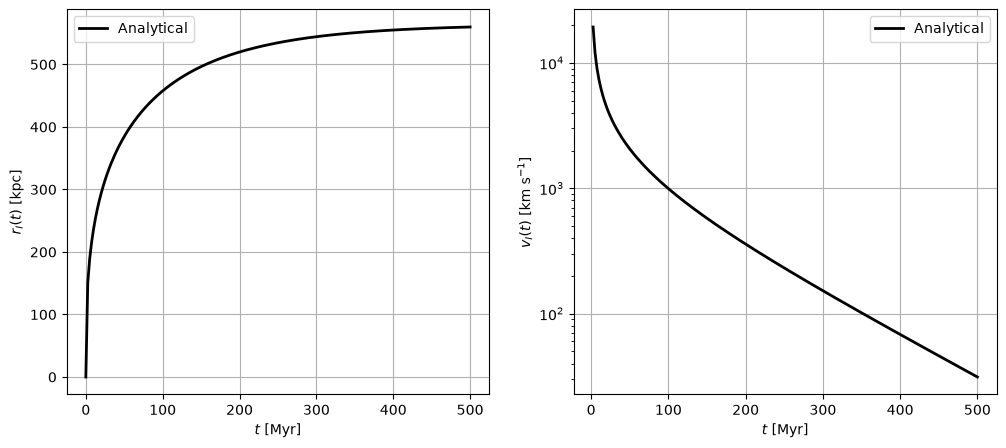

In [5]:
fig, axs = plt.subplots(figsize=(12,5), ncols=2, nrows=1)

axs[0].plot(t_analytical, r_analytical, color='black', ls='-', label="Analytical", lw=2)
axs[0].set_ylabel("$r_I(t)$ [kpc]")

axs[1].semilogy(t_analytical[1:],v_analytical,color='black',label="Analytical",lw=2)
axs[1].set_ylabel("$v_I(t)$ [km s$^{-1}$]")

for ax in axs:
    ax.set_xlabel("$t$ [Myr]")
    ax.grid()
    ax.legend()

## Numerical Solution

Here, we use pyC$^2$Ray to compute the I-front and test whether it provides the correct solution.

The coarseness of the numerical solution depends on the number of time steps. Here, we define the number of redshift steps we want to output. Increasing the value of `numzred` will refine the numerical solution and increase the computing time (`numzred=10` takes approximately __15 minutes__).

In [6]:
numzred = 10

Define some global parameters and instance the test simulation class.

In [7]:
# Global parameters
num_steps_between_slices = 1

# Create C2Ray object
sim = pc2r.C2Ray_Test(paramfile='validation/parameters_ifront.yml')


                 _________   ____            
    ____  __  __/ ____/__ \ / __ \____ ___  __
   / __ \/ / / / /    __/ // /_/ / __ `/ / / /
  / /_/ / /_/ / /___ / __// _, _/ /_/ / /_/ /
 / .___/\__, /\____//____/_/ |_|\__,_/\__, /
/_/    /____/                        /____/

Welcome! Mesh size is N = 256.
Simulation Box size (comoving Mpc): 1.620e+00
Cosmology is off.
Using Black-Body sources with effective temperature T = 5.0e+04 K and Radius  1.437e-11 rsun
Spectrum Frequency Range: 3.288e+15 to 1.316e+17 Hz
This is Energy:           1.360e+01 to 5.442e+02 eV
Integrating photoionization rates tables...
INFO: No heating rates


Successfully copied radiation tables to GPU memory.

---- Calculated Clumping Factor (constant model):
 min, mean and max clumping : 5.000e+00  5.000e+00  5.000e+00

---- Calculated Mean-Free Path (constant model):
Maximum comoving distance for photons from source mfp = 15.00 cMpc (constant model).
 This corresponds to 2370.048 grid cells.

Using ASORA Raytracing ( q_max = 384 )
Running in non-MPI (single-GPU/CPU) mode
Starting simulation... 


Running: "C2Ray Test"


Read the source file and define some redshift step.

In [8]:
# Generate redshift list (test case)
t_evol = 5e8 # years
zred_array = sim.generate_redshift_array(numzred+1,t_evol/numzred)

# Read sources
numsrc = 1
srcpos, srcflux = sim.read_sources("validation/src_ifront.txt", numsrc)

show_plot = True
xc = np.linspace(0, sim.boxsize*1000, sim.N)

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.200e-03
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.97s.
Doing Chemistry... 

took  1.3 s.
Number of non-converged points: 19 of 16777216 ( 0.000 % ), Relative change in ionfrac:  1.67e+03
Rank=0 is doing Raytracing... 

took 0.85s.
Doing Chemistry... 

took  1.3 s.
Number of non-converged points: 32 of 16777216 ( 0.000 % ), Relative change in ionfrac:  1.12e-03
Rank=0 is doing Raytracing... 

...

took  1.4 s.
Number of non-converged points: 26118 of 16777216 ( 0.156 % ), Relative change in ionfrac:  1.41e-04
Rank=0 is doing Raytracing... 

took 0.88s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 21438 of 16777216 ( 0.128 % ), Relative change in ionfrac:  1.01e-04
Rank=0 is doing Raytracing... 

took 0.79s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 17358 of 16777216 ( 0.103 % ), Relative change in ionfrac:  7.23e-05
Multiple source convergence reached after 87 ray-tracing iterations.


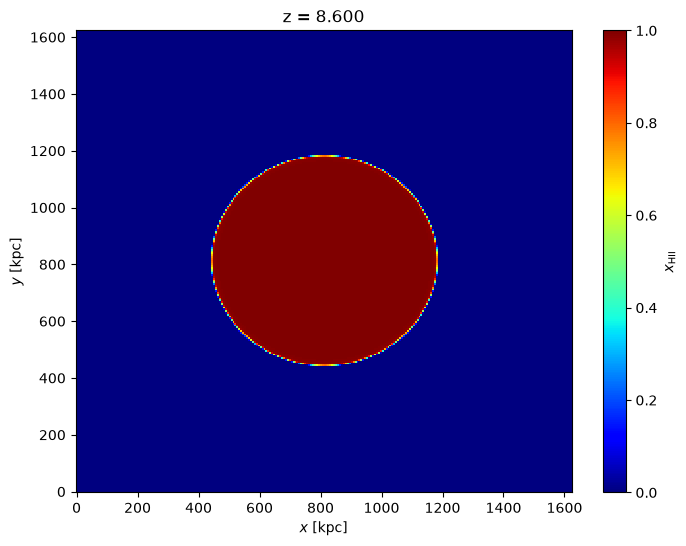

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 5.024e-02
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.94s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 291880 of 16777216 ( 1.740 % ), Relative change in ionfrac:  3.73e+01
Rank=0 is doing Raytracing... 

took 0.86s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 112420 of 16777216 ( 0.670 % ), Relative change in ionfrac:  3.45e-02
Rank=0 is doing Raytracing... 

...

took 0.85s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 58506 of 16777216 ( 0.349 % ), Relative change in ionfrac:  1.21e-04
Rank=0 is doing Raytracing... 

took 0.81s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 44500 of 16777216 ( 0.265 % ), Relative change in ionfrac:  8.94e-05
Multiple source convergence reached after 39 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

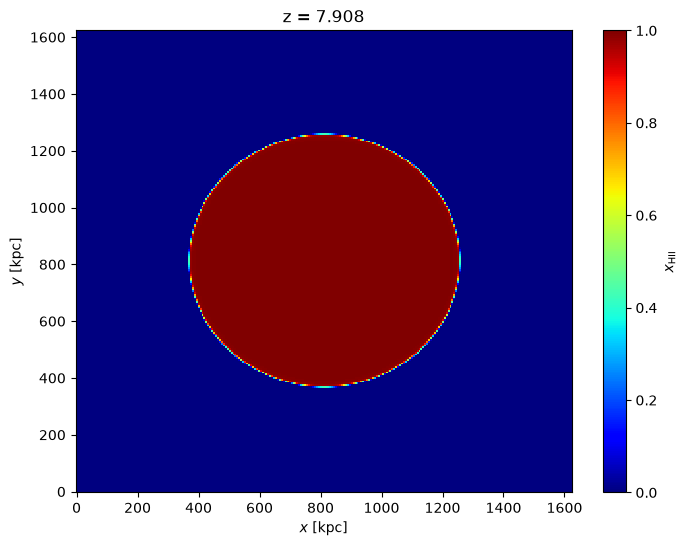

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 8.591e-02
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.91s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 348818 of 16777216 ( 2.079 % ), Relative change in ionfrac:  2.16e+01
Rank=0 is doing Raytracing... 

took 0.87s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 160180 of 16777216 ( 0.955 % ), Relative change in ionfrac:  2.34e-02
Rank=0 is doing Raytracing... 

...

took 0.81s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 68814 of 16777216 ( 0.410 % ), Relative change in ionfrac:  1.05e-04
Rank=0 is doing Raytracing... 

took 0.91s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 53358 of 16777216 ( 0.318 % ), Relative change in ionfrac:  7.81e-05
Multiple source convergence reached after 31 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

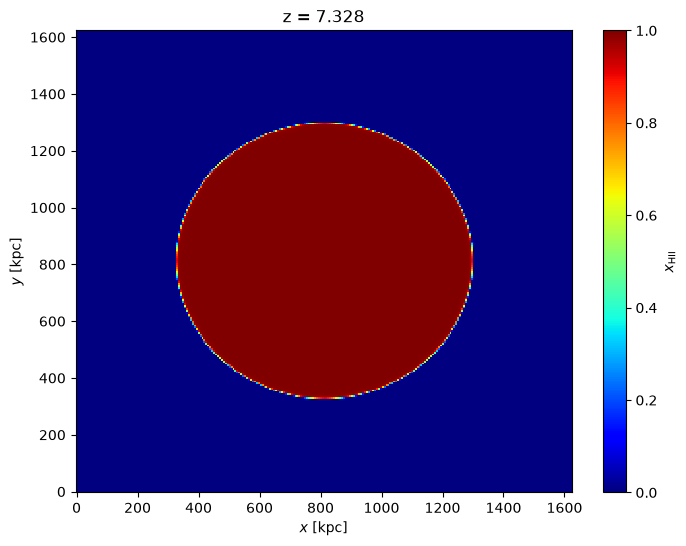

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.118e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.86s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 340242 of 16777216 ( 2.028 % ), Relative change in ionfrac:  1.64e+01
Rank=0 is doing Raytracing... 

took 0.87s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 186292 of 16777216 ( 1.110 % ), Relative change in ionfrac:  1.80e-02
Rank=0 is doing Raytracing... 

...

took 0.82s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 81766 of 16777216 ( 0.487 % ), Relative change in ionfrac:  1.03e-04
Rank=0 is doing Raytracing... 

took 0.88s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 62270 of 16777216 ( 0.371 % ), Relative change in ionfrac:  7.70e-05
Multiple source convergence reached after 26 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

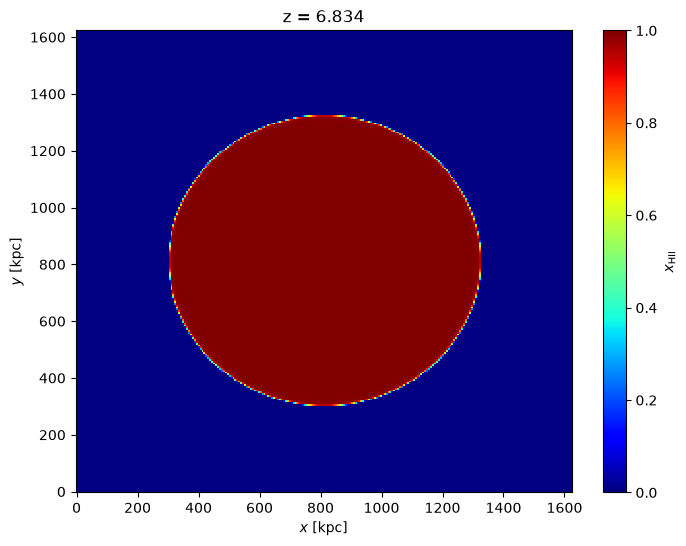

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.306e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.88s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 308868 of 16777216 ( 1.841 % ), Relative change in ionfrac:  1.40e+01
Rank=0 is doing Raytracing... 

took 0.89s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 198724 of 16777216 ( 1.184 % ), Relative change in ionfrac:  1.45e-02
Rank=0 is doing Raytracing... 

...

took 0.81s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 96760 of 16777216 ( 0.577 % ), Relative change in ionfrac:  1.14e-04
Rank=0 is doing Raytracing... 

took 0.82s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 75920 of 16777216 ( 0.453 % ), Relative change in ionfrac:  8.46e-05
Multiple source convergence reached after 22 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

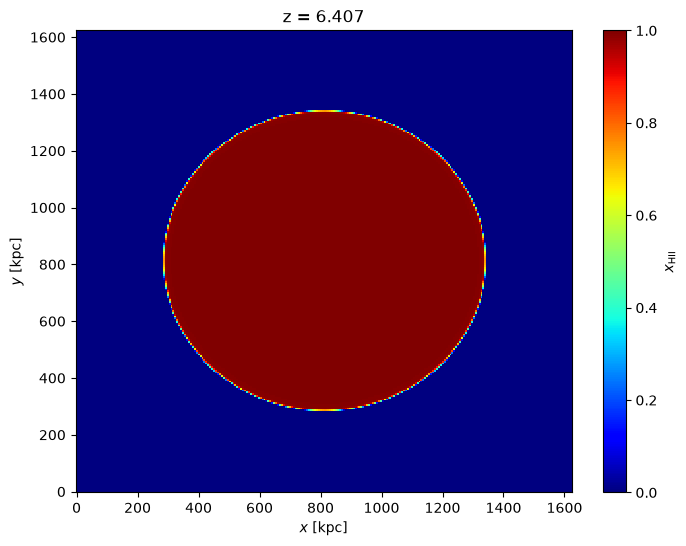

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.442e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.86s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 279586 of 16777216 ( 1.666 % ), Relative change in ionfrac:  1.26e+01
Rank=0 is doing Raytracing... 

took 0.70s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 203256 of 16777216 ( 1.212 % ), Relative change in ionfrac:  1.14e-02
Rank=0 is doing Raytracing... 

...

took 0.93s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 102824 of 16777216 ( 0.613 % ), Relative change in ionfrac:  1.15e-04
Rank=0 is doing Raytracing... 

took 0.76s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 80280 of 16777216 ( 0.479 % ), Relative change in ionfrac:  8.49e-05
Multiple source convergence reached after 19 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

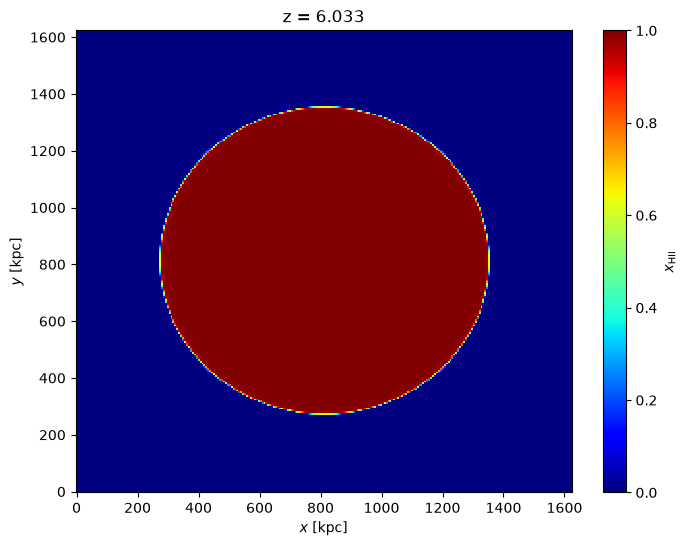

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.540e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.79s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 254792 of 16777216 ( 1.519 % ), Relative change in ionfrac:  1.18e+01
Rank=0 is doing Raytracing... 

took 0.89s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 201100 of 16777216 ( 1.199 % ), Relative change in ionfrac:  8.68e-03
Rank=0 is doing Raytracing... 

...

took 0.87s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 108718 of 16777216 ( 0.648 % ), Relative change in ionfrac:  1.18e-04
Rank=0 is doing Raytracing... 

took 0.87s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 86534 of 16777216 ( 0.516 % ), Relative change in ionfrac:  8.78e-05
Multiple source convergence reached after 16 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

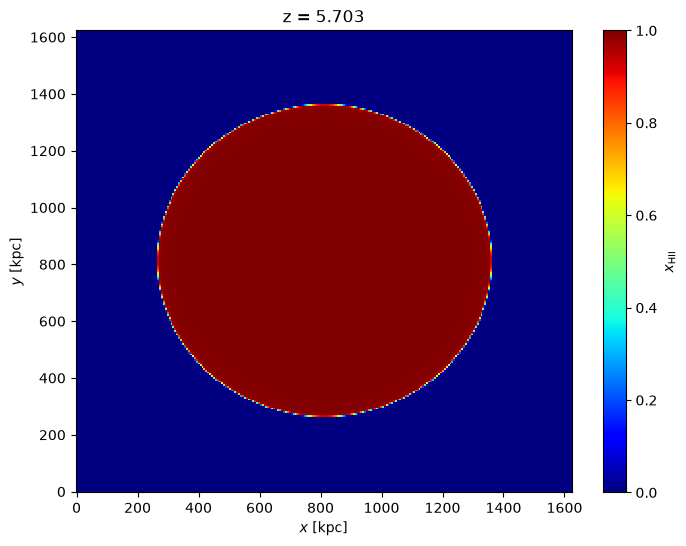

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.611e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.92s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 234688 of 16777216 ( 1.399 % ), Relative change in ionfrac:  1.13e+01
Rank=0 is doing Raytracing... 

took 0.90s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 205972 of 16777216 ( 1.228 % ), Relative change in ionfrac:  6.86e-03
Rank=0 is doing Raytracing... 

...

took 0.78s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 108806 of 16777216 ( 0.649 % ), Relative change in ionfrac:  1.31e-04
Rank=0 is doing Raytracing... 

took 0.72s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 78078 of 16777216 ( 0.465 % ), Relative change in ionfrac:  8.97e-05
Multiple source convergence reached after 12 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

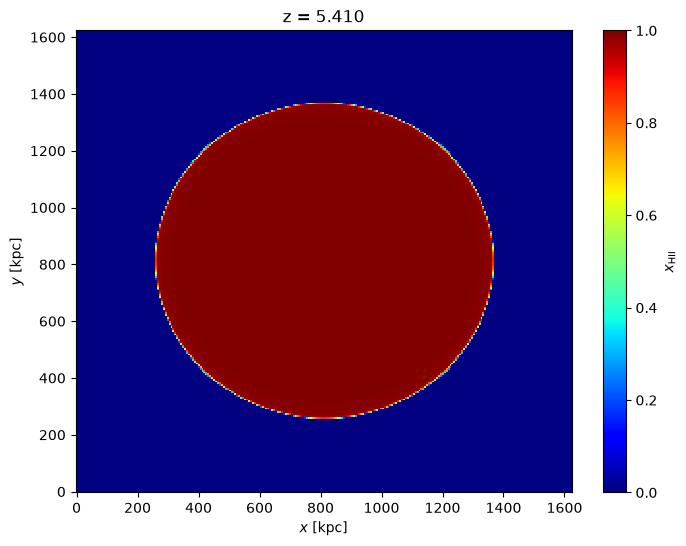

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.662e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.83s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 209404 of 16777216 ( 1.248 % ), Relative change in ionfrac:  1.09e+01
Rank=0 is doing Raytracing... 

took 0.92s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 197368 of 16777216 ( 1.176 % ), Relative change in ionfrac:  4.76e-03
Rank=0 is doing Raytracing... 

...

took 0.87s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 108400 of 16777216 ( 0.646 % ), Relative change in ionfrac:  1.31e-04
Rank=0 is doing Raytracing... 

took 0.76s.
Doing Chemistry... 

took  1.4 s.
Number of non-converged points: 67872 of 16777216 ( 0.405 % ), Relative change in ionfrac:  8.09e-05
Multiple source convergence reached after 10 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

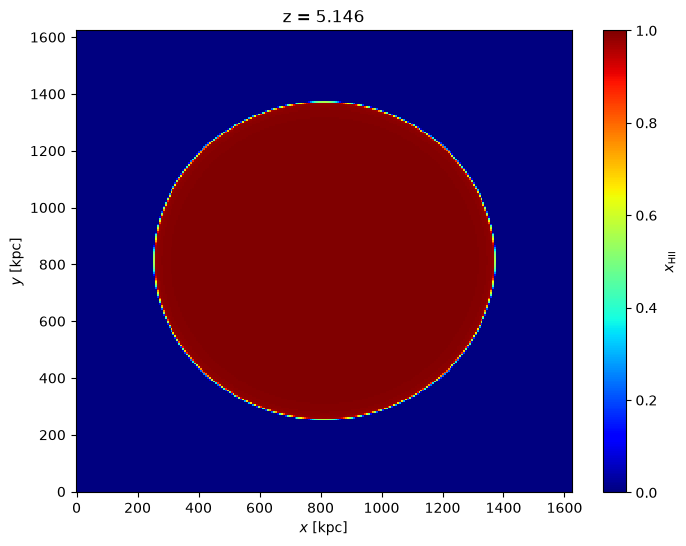

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 6.328e-03
dt [years]: 5.000e+07
Running on 1 source(s), total normalized ionizing flux: 1.00e+06
Mean density (cgs): 1.870e-04, Mean ionized fraction: 1.699e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... 

took 0.92s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 202574 of 16777216 ( 1.207 % ), Relative change in ionfrac:  1.07e+01
Rank=0 is doing Raytracing... 

took 0.93s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 189206 of 16777216 ( 1.128 % ), Relative change in ionfrac:  3.20e-03
Rank=0 is doing Raytracing... 

...

took 0.81s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 83592 of 16777216 ( 0.498 % ), Relative change in ionfrac:  1.03e-04
Rank=0 is doing Raytracing... 

took 0.76s.
Doing Chemistry... 

took  1.5 s.
Number of non-converged points: 53114 of 16777216 ( 0.317 % ), Relative change in ionfrac:  6.12e-05
Multiple source convergence reached after 9 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

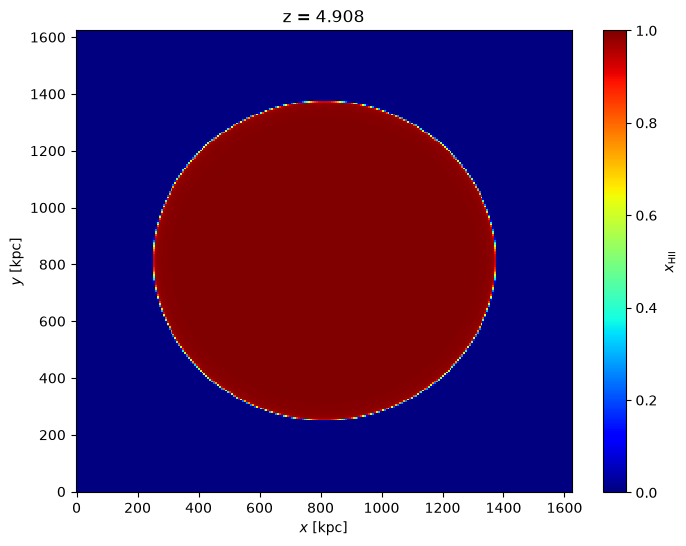

<Figure size 640x480 with 0 Axes>

In [9]:
# Start the timer ot measure the wall clock time
timer = pc2r.Timer()
timer.start()

# Loop over redshifts
for k in range(len(zred_array)-1):
    # Compute timestep of current redshift slice
    zi = zred_array[k]
    zf = zred_array[k+1]

    sim.printlog("\n==============\nDoing redshift %.3f to %.3f\n==============\n" %(zi, zf), sim.logfile)

    # Compute timestep of current redshift slice
    dt = sim.set_timestep(zi,zf,num_steps_between_slices)
    
    # Write output
    sim.write_output(zi)
    
    # Set density (when cosmological is false, zi has no effect)
    sim.density_init(zi)
    
    # Set redshift to current slice redshift
    sim.zred = zi
 
    # Do num_steps_between_slices timesteps
    for t in range(num_steps_between_slices):
        sim.printlog("\n --- Timestep %d. Redshift: z = %.3f --- \n" %(t+1, sim.zred), sim.logfile)

        # Evolve Cosmology: increment redshift and scale physical quantities (density, proper cell size, etc.). If cosmology is disabled in parameter, this step does nothing (checked internally by the class)
        sim.cosmo_evolve(dt)

        # Evolve the simulation: raytrace -> photoionization rates -> chemistry -> until convergence
        sim.evolve3D(dt, srcflux, srcpos)
        
        # Register elapsed Wall clock time
        tnow = timer.lap('k=%d, t=%d' %(k,t))
    
    # Show results at each redshift step
    if show_plot:
        fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=1)
        ax.set_title('z = %.3f' %sim.zred)
        im = ax.pcolormesh(xc, xc, sim.xh[:,:,sim.N//2], vmin=0, vmax=1, cmap='jet')
        plt.colorbar(im, ax=ax, label=r'$x_\mathrm{HII}$')
        ax.set_xlabel('$x$ [kpc]'), ax.set_ylabel('$y$ [kpc]')
        plt.show(), plt.clf()

# Write final output
sim.write_output(zf)

# stop the timer and print the summary
timer.stop()
sim.printlog(timer.summary, sim.logfile)

Let's have a look the wall clock time for this run.

In [10]:
print(timer.summary)


--- TIMER SUMMARY ---
 step 1: 3m 22.33s - k=0, t=0
 step 2: 1m 33.99s - k=1, t=0
 step 3: 1m 14.65s - k=2, t=0
 step 4: 1m 3.79s - k=3, t=0
 step 5: 53.48s - k=4, t=0
 step 6: 47.57s - k=5, t=0
 step 7: 39.08s - k=6, t=0
 step 8: 30.53s - k=7, t=0
 step 9: 24.96s - k=8, t=0
 step 10: 23.00s - k=9, t=0
Elapsed time: 10m 53.79s 


Here, we calculate the numerical solution for $r_I$. We define the I-front position as the point where the gas is 50% ionized. Here, we use a simple interpolation for a line of sight starting at the center of the box.

The I-front velocity, $v_I$, was obtained by simple finite-differencing of its position based on the current and previous time steps.

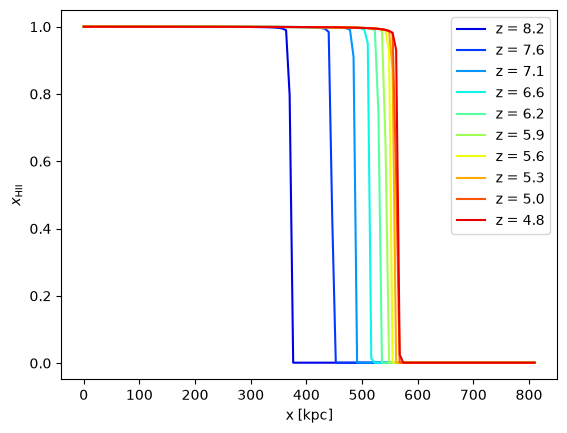

(None, None)

<Figure size 640x480 with 0 Axes>

In [11]:
# get half box length for interpolation in kpc
xc = np.linspace(0, sim.boxsize*1000/2, sim.N//2)

# get time of the corresponding redshift step
t_num = (sim.cosmology.age(zred_array) - sim.cosmology.age(sim.zred_0)).to('Myr')
t_aveg = 0.5*(t_num[1:]+t_num[:-1])

# get numerical radius and velocity
r_num = np.zeros_like(zred_array)
v_num = np.zeros(zred_array.size-1)

for k, z in enumerate(zred_array):
    # load ionized fraction
    xh = np.load('%sxfrac_%.3f.npy' %(sim.results_basename, z))
    
    # line of sight from the center to the box side
    los_xh = xh[sim.N//2:,sim.N//2,sim.N//2]
    
    # Compute the I-front radius at 50% ionized
    r_num[k] = np.interp(0.5, np.flip(los_xh), np.flip(xc)) 
    
    # Compute the I-front velocity
    if(k > 0):
        v_num[k-1] = ((r_num[k] - r_num[k-1])/(t_num[k]-t_num[k-1]) * u.kpc).to('km/s').value
        
        # plt the xHII profile
        plt.plot(xc, los_xh, label='z = %.1f' %z, color=plt.cm.jet(k/zred_array.size))
        plt.legend()
        
plt.xlabel('x [kpc]'), plt.ylabel(r'$x_\mathrm{HII}$')
plt.show(), plt.clf()

We plot the final result and compare the numerical and the analytical solutions. Despite employing only a few redshift steps (`numzred = 10`), the numerical solution agrees well with the analytical solution.

Increasing the value of `numzred`, for instance to 100, will have a less coarse numerical solution however, it will increase the computing time substantially.

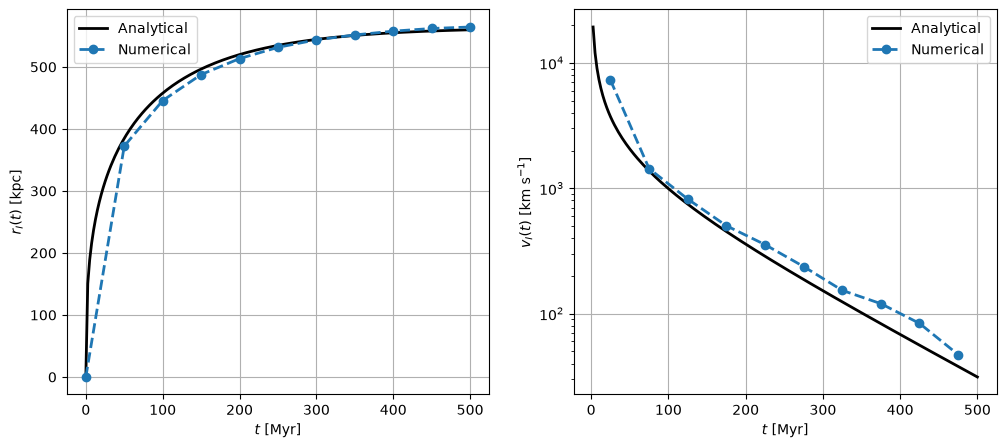

In [12]:
fig, axs = plt.subplots(figsize=(12,5), ncols=2, nrows=1)

axs[0].plot(t_analytical, r_analytical, color='black', ls='-', label="Analytical", lw=2)
axs[0].plot(t_num, r_num, color='tab:blue', marker='o', ls='--', label="Numerical", lw=2)
axs[0].set_ylabel("$r_I(t)$ [kpc]")

axs[1].semilogy(t_analytical[1:],v_analytical,color='black',label="Analytical",lw=2)
axs[1].plot(t_aveg, v_num, color='tab:blue', marker='o', ls='--', label="Numerical", lw=2)
axs[1].set_ylabel("$v_I(t)$ [km s$^{-1}$]")

for ax in axs:
    ax.set_xlabel("$t$ [Myr]")
    ax.grid()
    ax.legend()

## 2. Shadow Test

Another standard example scenario for testing raytracing algorithms is the so-called _shadow test_ [(Iliev+ 2006)](https://arxiv.org/abs/astro-ph/0603199). 

This consists of an ionizing front (_I-front_) interacting with denser regions, a density clump, and the formation of a shadow behind these regions.

In [13]:
import pyc2ray as pc2r
import numpy as np, matplotlib.pyplot as plt

from matplotlib.colors import LogNorm

Define some global parameters and instance the test simulation class.

In [14]:
# Global parameters
num_steps_between_slices = 10
numzred = 2
show_plot = True

# Create C2Ray object
sim = pc2r.C2Ray_Test(paramfile='validation/parameters_shadow.yml')


                 _________   ____            
    ____  __  __/ ____/__ \ / __ \____ ___  __
   / __ \/ / / / /    __/ // /_/ / __ `/ / / /
  / /_/ / /_/ / /___ / __// _, _/ /_/ / /_/ /
 / .___/\__, /\____//____/_/ |_|\__,_/\__, /
/_/    /____/                        /____/

Welcome! Mesh size is N = 128.
Simulation Box size (comoving Mpc): 1.400e-02
Cosmology is off.
Using power-law opacity with 10000 table points between tau=10^(-20) and tau=10^(4)
Using Black-Body sources with effective temperature T = 5.0e+04 K and Radius  1.437e-11 rsun
Spectrum Frequency Range: 3.288e+15 to 1.316e+17 Hz
This is Energy:           1.360e+01 to 5.442e+02 eV
Integrating photoionization rates tables...
INFO: No heating rates
Successfully copied radiation tables to GPU memory.

---- Calculated Clumping Factor (constant model):
 min, mean and max clumping : 1.000e+00  1.000e+00  1.000e+00

---- Calculated Mean-Free Path (constant model):
Maximum comoving distance for photons from source mfp = 15.00 cMp

Read the source file and define some redshift step.

In [15]:
# Generate redshift list (test case)
zred_array = sim.generate_redshift_array(numzred, 1e7)

# Read sources
numsrc = 1
srcpos, srcflux = sim.read_sources("validation/src.txt", numsrc)

## Clump region

Generate a density field with a clump reagion.

In [16]:
# Setup density
avgdens = 1e-4 #sim.avg_dens

# box side in kpc
xc = np.linspace(0, sim.boxsize*1000, sim.N)
X,Y,Z = np.meshgrid(xc,xc,xc)

# Denser region position and size
#shadow_pos = np.array([76,76,sim.N//2])
shadow_pos = np.array([int(sim.N*3/4),int(sim.N*3/4),sim.N//2])
shadow_radius = 8
shadow_fact = 10

# background 
ndens = avgdens*np.ones((sim.N,sim.N,sim.N))
for i in range(ndens.shape[0]):
    for j in range(ndens.shape[1]):
        for k in range(ndens.shape[2]):
            if (i-shadow_pos[0])**2 + (j-shadow_pos[1])**2 + (k-shadow_pos[2])**2 < shadow_radius**2:
                ndens[i,j,k] = shadow_fact*avgdens

Plot the density field to look at the denser clump.

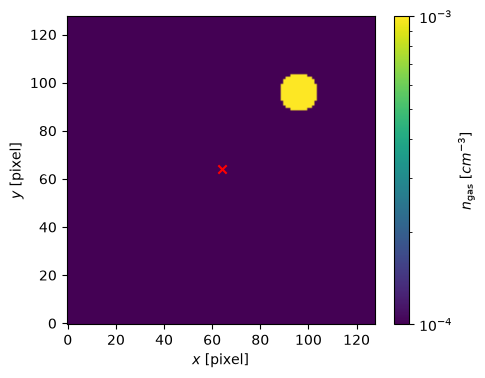

(None, None)

<Figure size 640x480 with 0 Axes>

In [17]:
fig, ax = plt.subplots(figsize=(5, 4), ncols=1, nrows=1)
im = ax.imshow(ndens[:,:,sim.N//2], norm=LogNorm(), origin='lower')

plt.scatter(x=srcpos[0], y=srcpos[1], marker='x', color='red')
plt.colorbar(im, ax=ax, label=r'$n_\mathrm{gas}$ $[cm^{-3}]$')
ax.set_xlabel('$x$ [pixel]') 
ax.set_ylabel('$y$ [pixel]')
plt.show(), plt.clf()

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 1.200e-03
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1123115 of 2097152 ( 53.554 % ), Relative change in ionfrac:  1.24e+02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 827132 of 2097152 ( 39.441 % ), Relative change in ionfrac:  4.47e-01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 595268 of 2097152 ( 28.385 % ), Relative change in ionfrac:  1.80e-01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 348580 of 2097152 ( 16.622 % ), Relative change in ionfrac:  5.24e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 142580 of 2097152 ( 6.799 % ), Relative change in ionfrac:  1.07e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.60e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.89e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.86e-05
Multiple source convergence reached after 8 ray-tracing iterations.


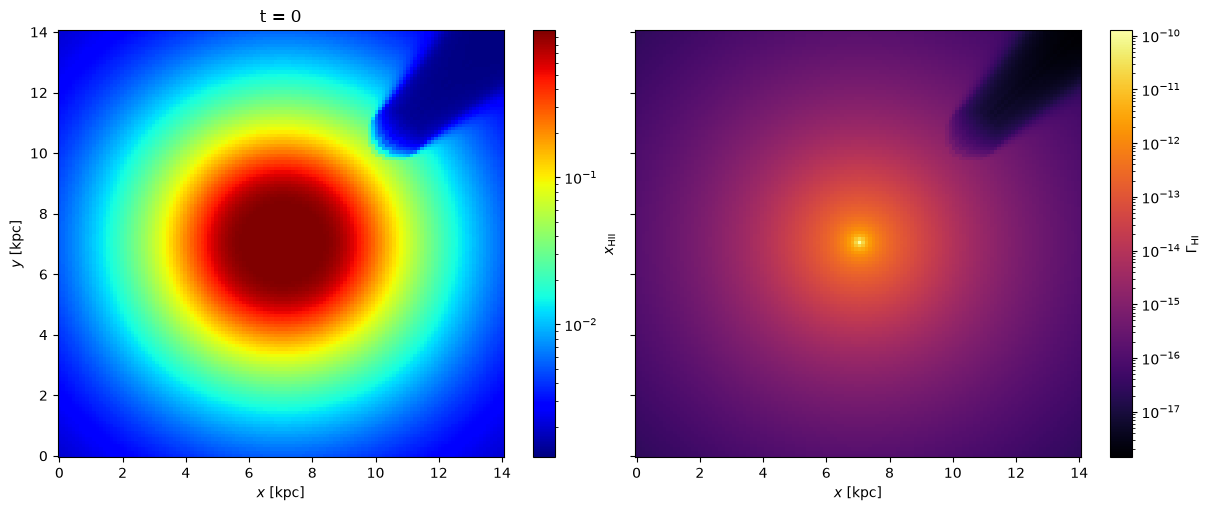

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 3.775e-02
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1698149 of 2097152 ( 80.974 % ), Relative change in ionfrac:  2.90e+01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 761102 of 2097152 ( 36.292 % ), Relative change in ionfrac:  8.17e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 306561 of 2097152 ( 14.618 % ), Relative change in ionfrac:  1.24e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.31e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.06e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  6.84e-06
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

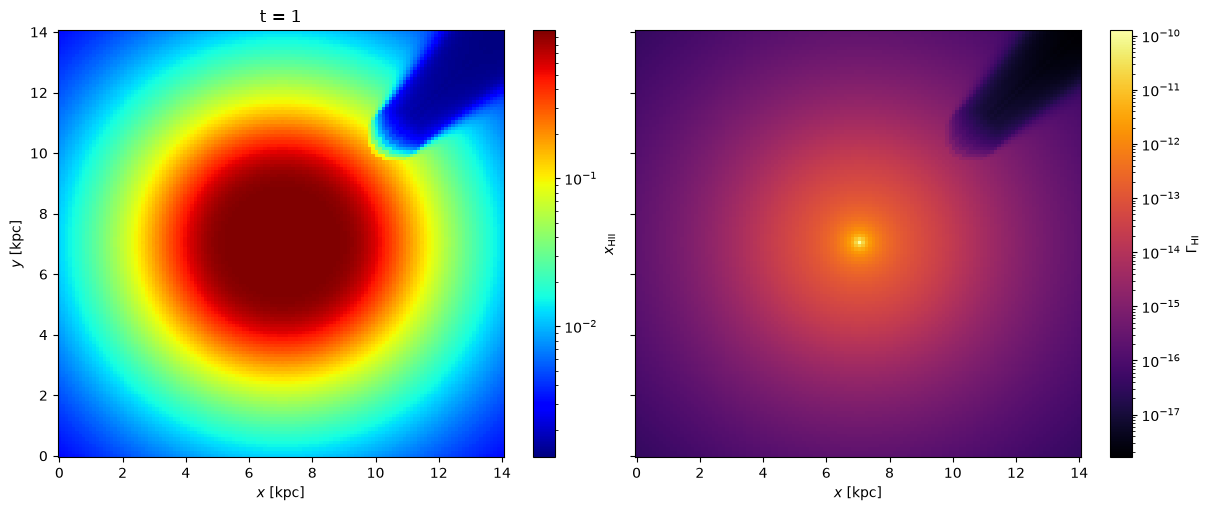

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 7.362e-02
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1826897 of 2097152 ( 87.113 % ), Relative change in ionfrac:  1.82e+01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 791095 of 2097152 ( 37.722 % ), Relative change in ionfrac:  4.01e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 164969 of 2097152 ( 7.866 % ), Relative change in ionfrac:  4.17e-03
Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  3.08e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.75e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

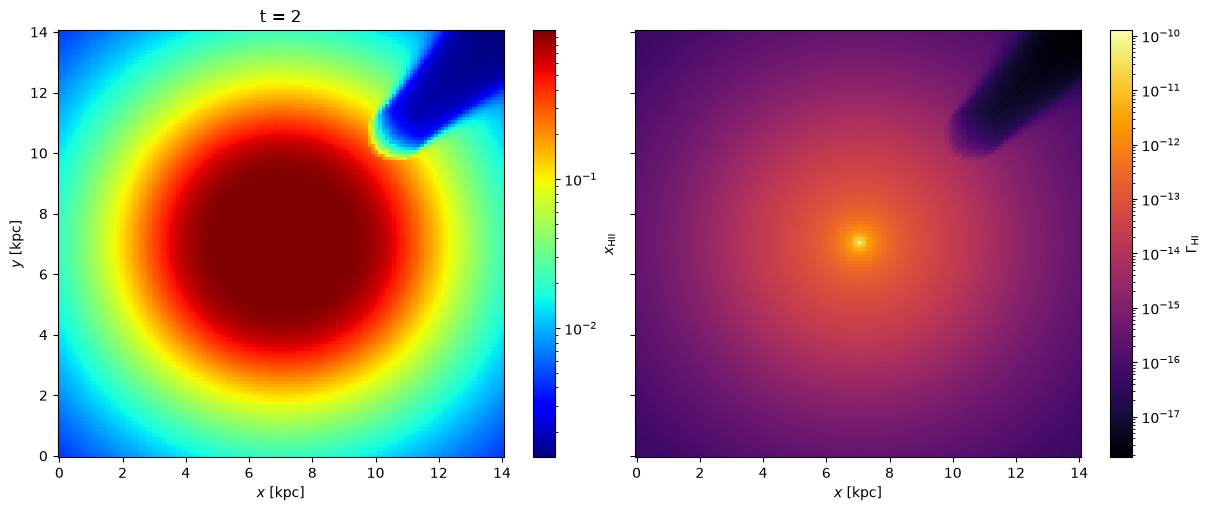

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 1.089e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1897803 of 2097152 ( 90.494 % ), Relative change in ionfrac:  1.33e+01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 814851 of 2097152 ( 38.855 % ), Relative change in ionfrac:  2.43e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.98e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.15e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.19e-06
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

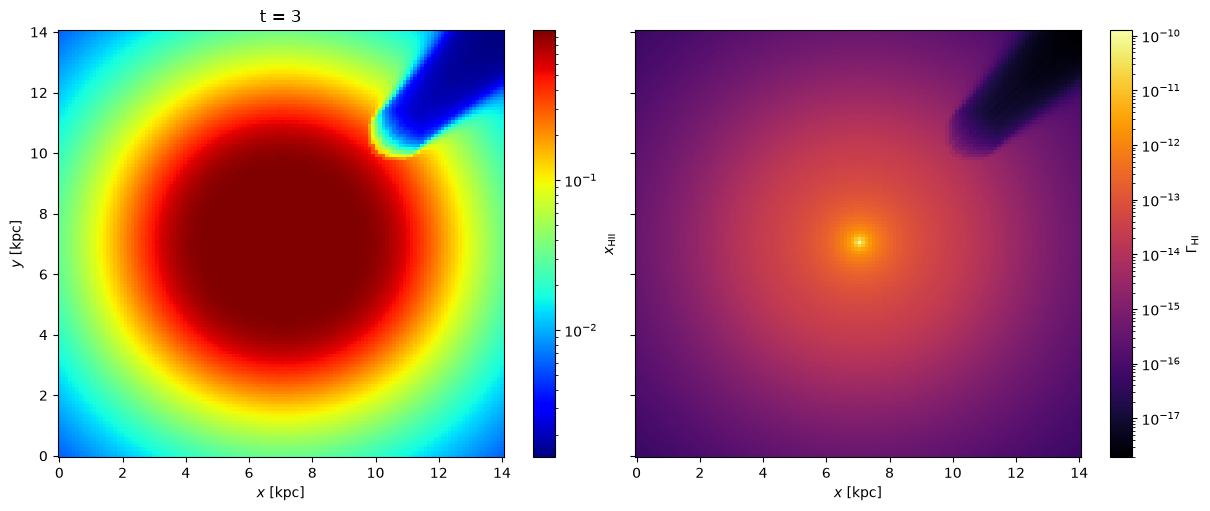

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 1.435e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1939291 of 2097152 ( 92.473 % ), Relative change in ionfrac:  1.05e+01
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 829498 of 2097152 ( 39.554 % ), Relative change in ionfrac:  1.65e-02
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.11e-03
Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.42e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

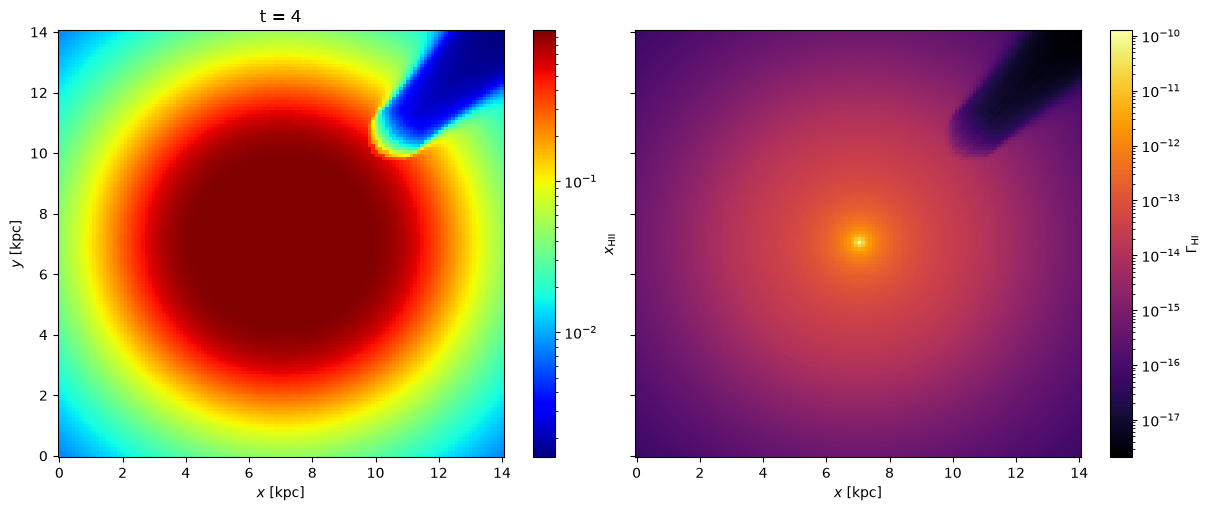

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 1.775e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1962767 of 2097152 ( 93.592 % ), Relative change in ionfrac:  8.60e+00
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 836404 of 2097152 ( 39.883 % ), Relative change in ionfrac:  1.20e-02
Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  6.98e-04
Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.93e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

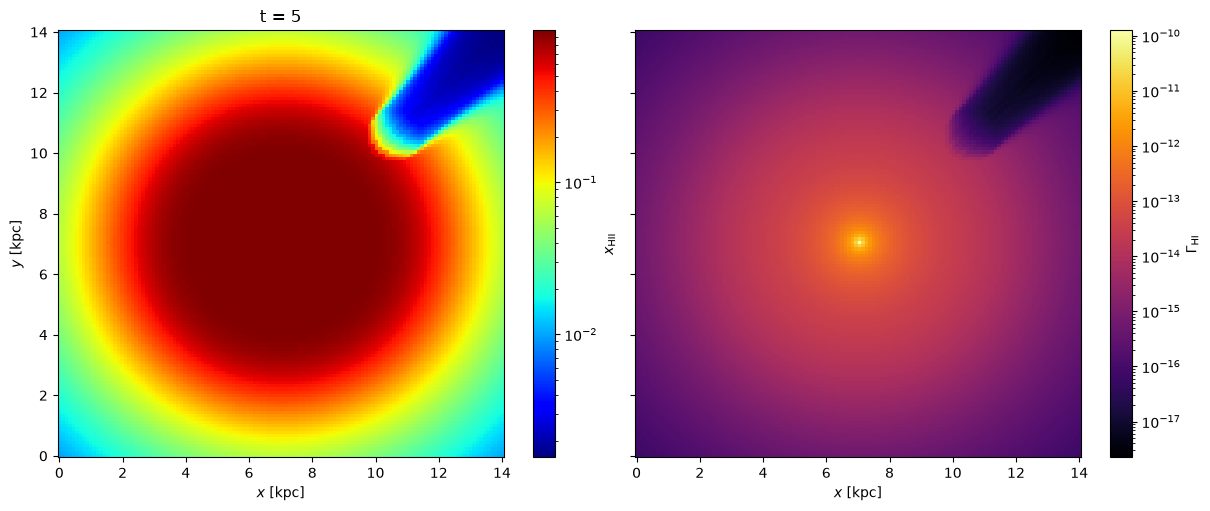

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 2.109e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1973414 of 2097152 ( 94.100 % ), Relative change in ionfrac:  7.29e+00
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 833375 of 2097152 ( 39.738 % ), Relative change in ionfrac:  9.13e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.68e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.74e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

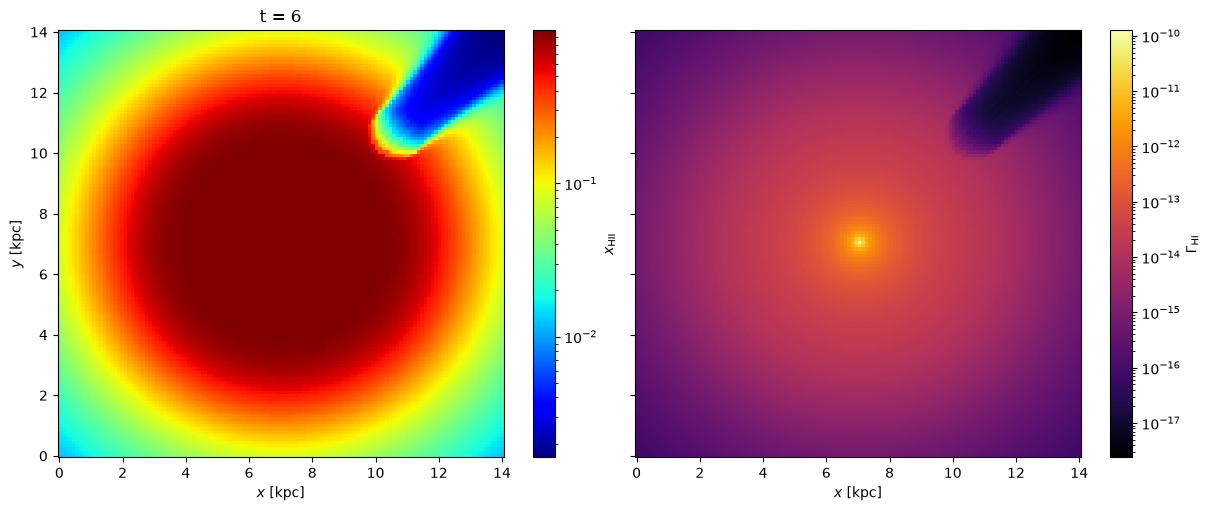

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 2.437e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1975200 of 2097152 ( 94.185 % ), Relative change in ionfrac:  6.31e+00
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 823283 of 2097152 ( 39.257 % ), Relative change in ionfrac:  7.18e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  3.30e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.10e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

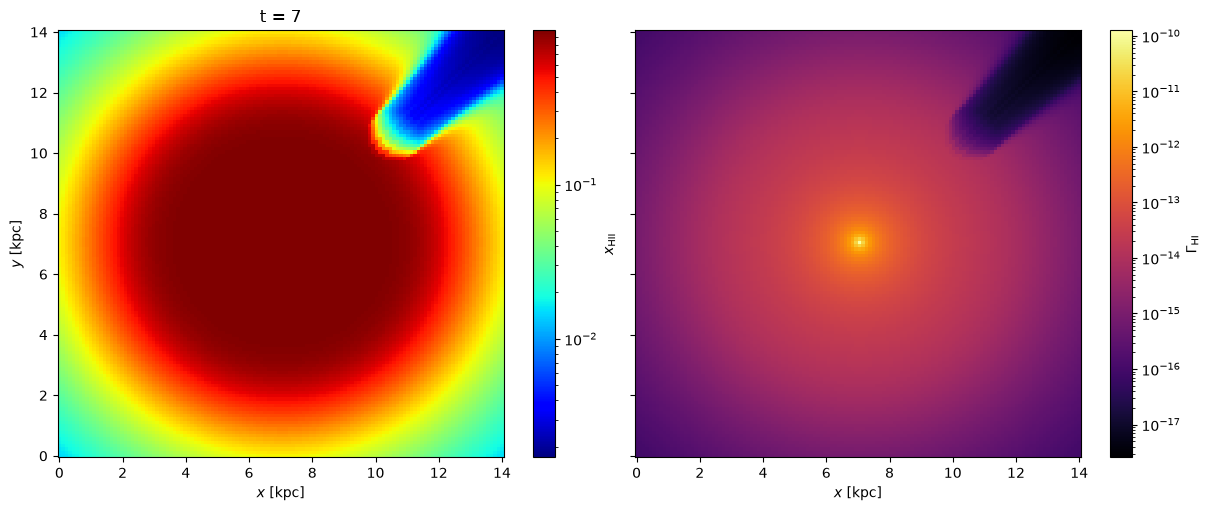

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 2.758e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1971706 of 2097152 ( 94.018 % ), Relative change in ionfrac:  5.55e+00
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 803691 of 2097152 ( 38.323 % ), Relative change in ionfrac:  5.79e-03
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.41e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  7.33e-06
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

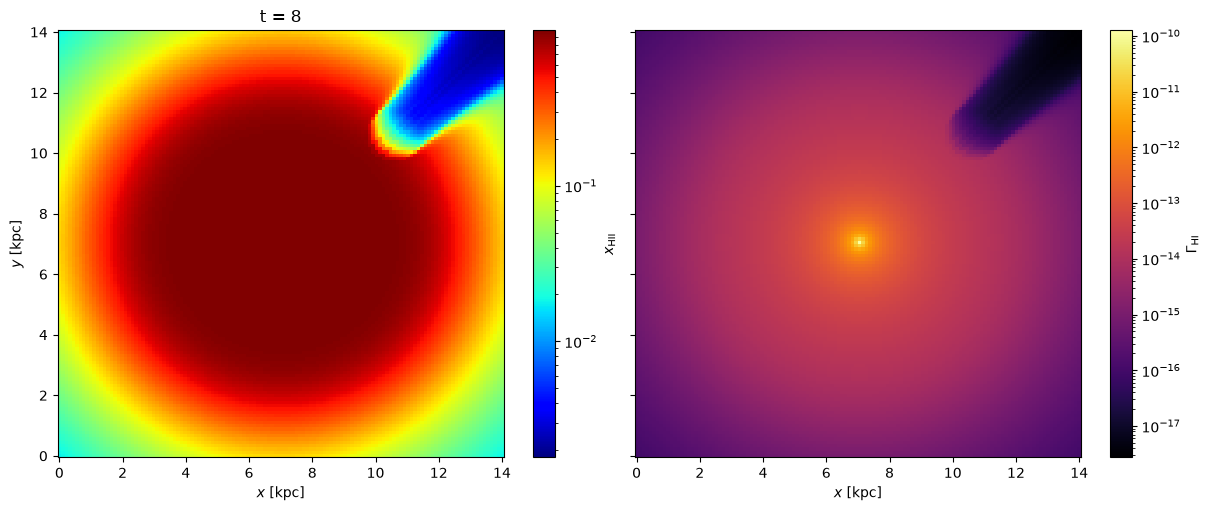

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 1.000e+06
Running on 1 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.009e-04, Mean ionized fraction: 3.072e-01
Convergence Criterion (Number of points):  0

Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 1963595 of 2097152 ( 93.632 % ), Relative change in ionfrac:  4.95e+00
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 774011 of 2097152 ( 36.908 % ), Relative change in ionfrac:  4.75e-03
Rank=0 is doing Raytracing... took 0.09s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.81e-04
Rank=0 is doing Raytracing... took 0.08s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.05e-06
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

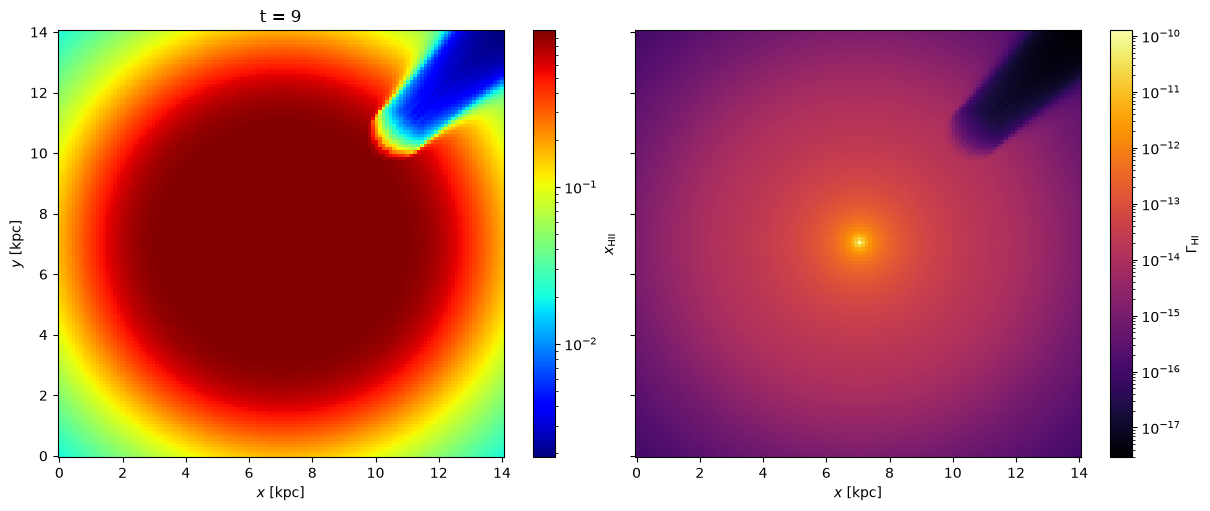

<Figure size 640x480 with 0 Axes>

In [18]:
# Start the timer ot measure the wall clock time
timer = pc2r.Timer()
timer.start()

# Loop over redshifts
for k in range(len(zred_array)-1):
    # Compute timestep of current redshift slice
    zi = zred_array[k]
    zf = zred_array[k+1]
    dt = sim.set_timestep(zi,zf,num_steps_between_slices)

    # Write output
    sim.write_output(zi)

    # Set density field (could be an actual cosmological field here)    
    if(sim.cosmological):
        # The comoving density which is then scaled to the correct redshift. In the timesteps, the density is then "diluted" gradually
        sim.set_constant_average_density(avgdens,0) 
    else:
        sim.ndens = ndens

    sim.printlog("\n=================================\nDoing redshift %.3f to %.3f\n=================================\n" %(zi, zf), sim.logfile)
 
    # Do num_steps_between_slices timesteps
    for t in range(num_steps_between_slices):
        sim.printlog("\n --- Timestep %d. Redshift: z = %.3f --- \n" %(t+1, sim.zred), sim.logfile)

        # Evolve Cosmology: increment redshift and scale physical quantities (density, proper cell size, etc.). If cosmology is disabled in parameter, this step does nothing (checked internally by the class)
        if(sim.cosmological):
            sim.cosmo_evolve(dt)

        # Evolve the simulation: raytrace -> photoionization rates -> chemistry -> until convergence
        sim.evolve3D(dt, srcflux, srcpos)
        
        # Register elapsed Wall clock time
        tnow = timer.lap('t=%d' %t)
        
        # Show results at each timesteps
        if show_plot:
            fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)

            axs[0].set_title('t = %d' %t)
            im = axs[0].pcolormesh(xc, xc, sim.xh[:,:,sim.N//2], norm=LogNorm(), cmap='jet')
            plt.colorbar(im, ax=axs[0], label=r'$x_\mathrm{HII}$')

            im = axs[1].pcolormesh(xc, xc, sim.phi_ion[:,:,sim.N//2], norm=LogNorm(), cmap='inferno')
            plt.colorbar(im, ax=axs[1], label=r'$\Gamma_\mathrm{HI}$')

            for ax in axs:
                ax.set_xlabel('$x$ [kpc]'), 
                ax.set_ylabel('$y$ [kpc]')
                ax.label_outer()
                
            plt.show(), plt.clf()
        
# Write final output
sim.write_output(zf)

# stop the timer and print the summary
timer.stop()
sim.printlog(timer.summary, sim.logfile)

Let's look at the wall clock time at each time step of our simulation.

In [19]:
print(timer.summary)


--- TIMER SUMMARY ---
 step 1: 4.33s - t=0
 step 2: 4.02s - t=1
 step 3: 3.36s - t=2
 step 4: 3.37s - t=3
 step 5: 2.93s - t=4
 step 6: 2.83s - t=5
 step 7: 2.83s - t=6
 step 8: 2.88s - t=7
 step 9: 2.99s - t=8
 step 10: 2.85s - t=9
Elapsed time: 32.93s 


## Final Result
Here, we plot the final result and highlight the denser region with contour lines.

We can notice that the radiation manages to propagate into the denser region. However, the neutral hydrogen in the denser region remains neutral despite the intense ionizing flux. 

Moreover, the HI gas in the shadow behind the clump is unaffected by radiation.

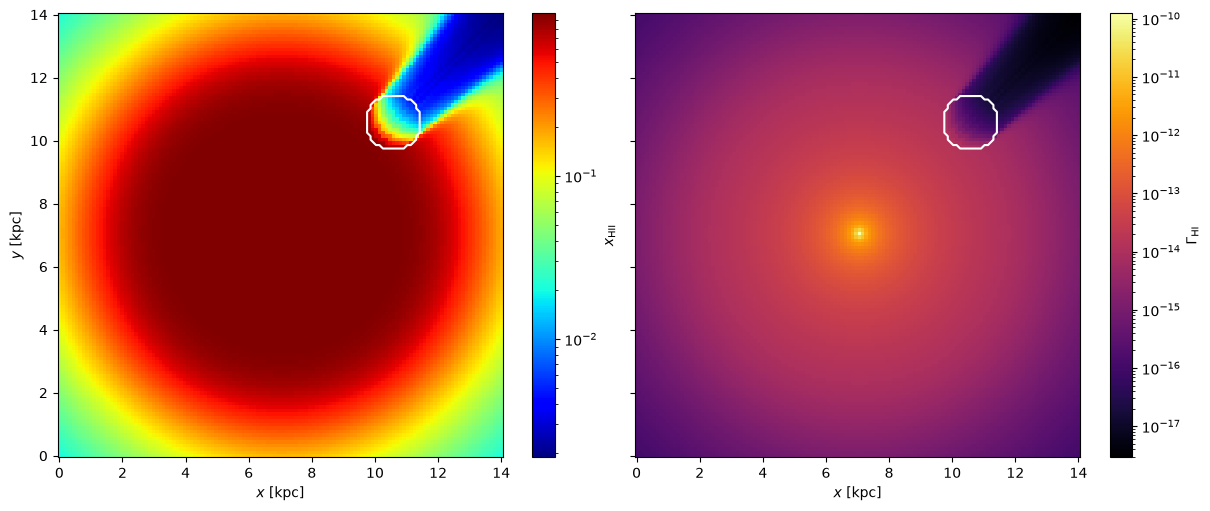

In [20]:
fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)

im = axs[0].pcolormesh(xc, xc, sim.xh[:,:,sim.N//2], norm=LogNorm(), cmap='jet')
plt.colorbar(im, ax=axs[0], label=r'$x_\mathrm{HII}$')

im = axs[1].pcolormesh(xc, xc, sim.phi_ion[:,:,sim.N//2], norm=LogNorm(), cmap='inferno')
plt.colorbar(im, ax=axs[1], label=r'$\Gamma_\mathrm{HI}$')

for ax in axs:
    ax.contour(xc, xc, sim.ndens[:,:,sim.N//2], levels=1, colors='white')
    ax.set_xlabel('$x$ [kpc]'), 
    ax.set_ylabel('$y$ [kpc]')
    ax.label_outer()

## 3. Multiple Sources Cosmological Test

A standard cosmological reionization setup: five sources in a homogeneous density field that is diluted by the cosmic expansion at each redshift step. Two cases, with the same five source positions (`parameters_mult_equal.yml` / `parameters_mult_bright.yml`, identical apart from the output folder):

- **3a. Same type of sources** (`src_mult_equal.txt`): all five sources emit $5\times10^{48}$ photons/s.
- **3b. Single source brighter than the others** (`src_mult_bright.txt`): the source at (96, 32, 64) keeps the 3a flux of $5\times10^{48}$ photons/s, the other four are reduced to a quarter, $1.25\times10^{48}$ photons/s (so the bright one is 4× the others).

**Note on the ReadTheDocs example.** The docs example (`docs/examples/multi_sources.ipynb`, `src_mult.txt`) uses fluxes from $5\times10^{46}$ to $5\times10^{54}$ photons/s, but was run with CPU raytracing (`gpu: 0`). The CPU (Fortran) raytracer computes the rates with the flux of the *last* source for every source (`normflux(NumSrc)` instead of `normflux(ns)` in `src/c2ray/raytracing.f90`), so its figure shows five equal $5\times10^{48}$ sources. Case 3a is that configuration, so it should look like the docs figure, and it does not depend on the bug, so it can be compared cell by cell with a CPU run.

In [21]:
import pyc2ray as pc2r
import numpy as np, matplotlib.pyplot as plt

import astropy.units as u
from matplotlib.colors import LogNorm

Both cases run the same loop: 10 redshift slices with 2 timesteps each, plotting the mid-plane ionized fraction and photoionization rate after every timestep.

In [22]:
def run_multi_sources(paramfile, srcfile, numsrc=5, numzred=10, num_steps_between_slices=2, show_plot=True):
    # Create C2Ray object
    sim = pc2r.C2Ray_Test(paramfile=paramfile)

    # Generate redshift list (test case) and read sources
    zred_array = sim.generate_redshift_array(numzred, 1e7)
    print(zred_array)
    srcpos, srcflux = sim.read_sources(srcfile, numsrc)

    xc = np.linspace(0, sim.boxsize*1000, sim.N)

    # Start the timer ot measure the wall clock time
    timer = pc2r.Timer()
    timer.start()

    # Loop over redshifts
    for k in range(len(zred_array)-1):
        # Compute timestep of current redshift slice
        zi = zred_array[k]
        zf = zred_array[k+1]
        dt = sim.set_timestep(zi,zf,num_steps_between_slices)

        # Write output
        sim.write_output(zi)

        # Set density field (could be an actual cosmological field here)
        sim.set_constant_average_density(ndens=sim.avg_dens, z=zi)

        sim.printlog("\n==========\nDoing redshift %.3f to %.3f\n==========\n" %(zi, zf), sim.logfile)

        # Do num_steps_between_slices timesteps
        for t in range(num_steps_between_slices):
            # redshift at the corresponding time step
            z_mid = sim.time2zred((sim.cosmology.age(zi) + dt*u.s*t).cgs.value)

            sim.printlog("\n --- Timestep %d. Redshift: z = %.3f --- \n" %(t+1, z_mid), sim.logfile)

            # Evolve Cosmology: increment redshift and scale physical quantities (density, proper cell size, etc.). If cosmology is disabled in parameter, this step does nothing (checked internally by the class)
            if(sim.cosmological):
                sim.cosmo_evolve(dt)

            # Evolve the simulation: raytrace -> photoionization rates -> chemistry -> until convergence
            sim.evolve3D(dt, srcflux, srcpos)

            # Register elapsed Wall clock time
            tnow = timer.lap('t=%d' %t)

            # Show results at each timesteps
            if show_plot:
                fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)

                axs[0].set_title('z = %.2f' %z_mid)
                im = axs[0].pcolormesh(xc, xc, sim.xh[:,:,sim.N//2], norm=LogNorm(), cmap='jet')
                plt.colorbar(im, ax=axs[0], label=r'$x_\mathrm{HII}$')

                im = axs[1].pcolormesh(xc, xc, sim.phi_ion[:,:,sim.N//2], norm=LogNorm(), cmap='inferno')
                plt.colorbar(im, ax=axs[1], label=r'$\Gamma_\mathrm{HI}$')

                for ax in axs:
                    ax.set_xlabel('$x$ [kpc]'),
                    ax.set_ylabel('$y$ [kpc]')
                    ax.label_outer()

                plt.show(), plt.clf()

    # Write final output
    sim.write_output(zf)

    # stop the timer and print the summary
    timer.stop()
    sim.printlog(timer.summary, sim.logfile)
    return sim, srcpos, srcflux, timer

### 3a. Same type of sources

All five sources emit $5\times10^{48}$ photons/s: five equal, overlapping HII regions are expected, as in the ReadTheDocs figure.


                 _________   ____            
    ____  __  __/ ____/__ \ / __ \____ ___  __
   / __ \/ / / / /    __/ // /_/ / __ `/ / / /
  / /_/ / /_/ / /___ / __// _, _/ /_/ / /_/ /
 / .___/\__, /\____//____/_/ |_|\__,_/\__, /
/_/    /____/                        /____/

Welcome! Mesh size is N = 128.
Simulation Box size (comoving Mpc): 1.400e-02
Cosmology is off.
Using power-law opacity with 10000 table points between tau=10^(-20) and tau=10^(4)
Using Black-Body sources with effective temperature T = 5.0e+04 K and Radius  1.437e-11 rsun
Spectrum Frequency Range: 3.288e+15 to 1.316e+17 Hz
This is Energy:           1.360e+01 to 5.442e+02 eV
Integrating photoionization rates tables...
INFO: No heating rates
Successfully copied radiation tables to GPU memory.

---- Calculated Clumping Factor (constant model):
 min, mean and max clumping : 1.000e+00  1.000e+00  1.000e+00

---- Calculated Mean-Free Path (constant model):
Maximum comoving distance for photons from source mfp = 15.00 cMp

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.200e-03
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 211895 of 2097152 ( 10.104 % ), Relative change in ionfrac:  3.67e+02
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

...

took  0.3 s.
Number of non-converged points: 100476 of 2097152 ( 4.791 % ), Relative change in ionfrac:  5.68e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 34480 of 2097152 ( 1.644 % ), Relative change in ionfrac:  1.64e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.19e-04
Multiple source convergence reached after 12 ray-tracing iterations.


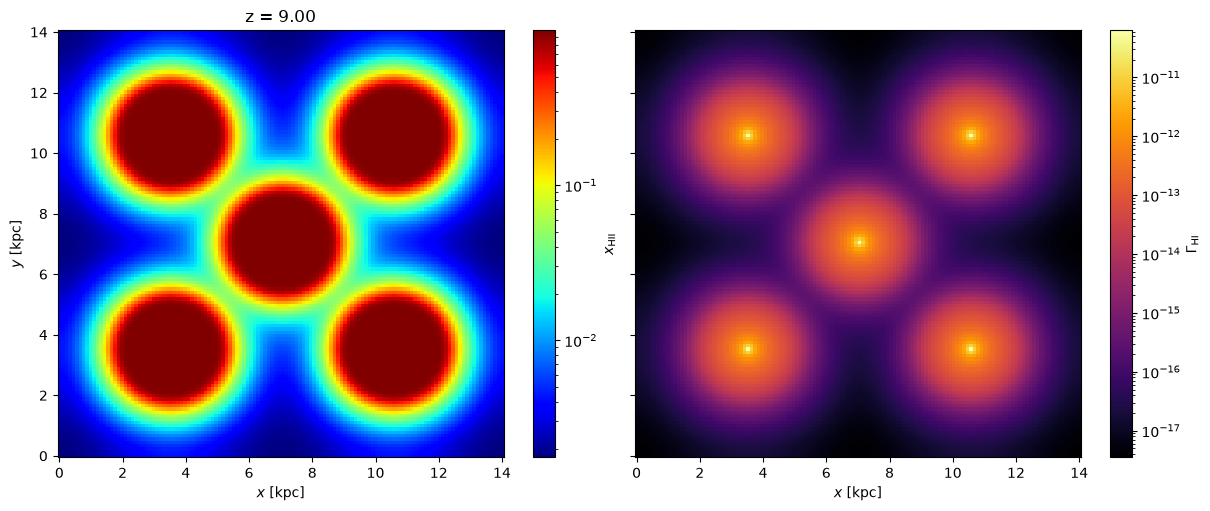

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 4.882e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 670760 of 2097152 ( 31.984 % ), Relative change in ionfrac:  2.68e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 438078 of 2097152 ( 20.889 % ), Relative change in ionfrac:  1.38e-01
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 50376 of 2097152 ( 2.402 % ), Relative change in ionfrac:  1.23e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.99e-04
Multiple source convergence reached after 8 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

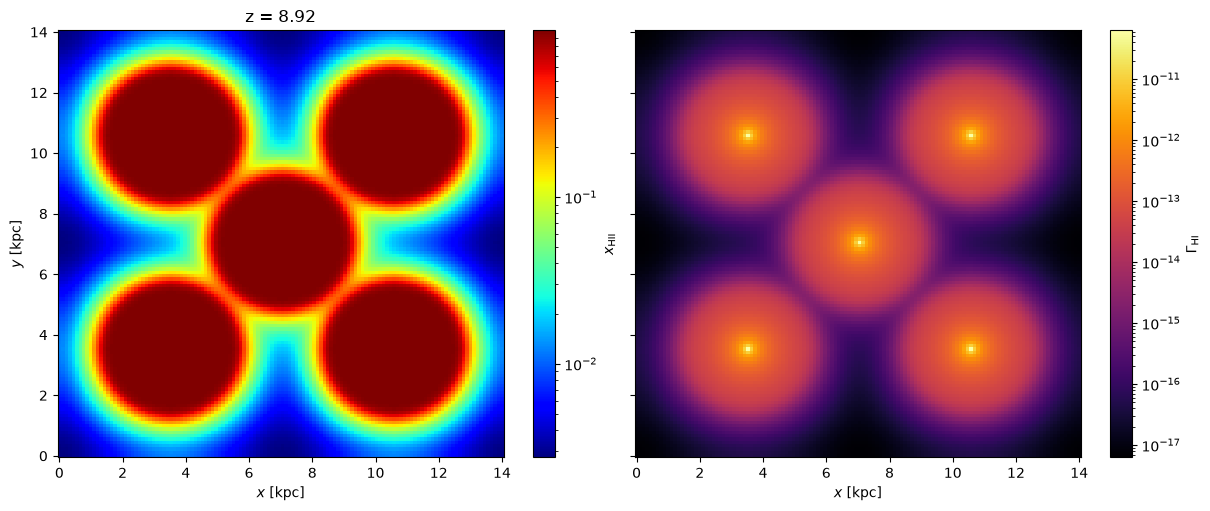

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 9.529e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 785534 of 2097152 ( 37.457 % ), Relative change in ionfrac:  1.54e+01
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 500314 of 2097152 ( 23.857 % ), Relative change in ionfrac:  8.09e-02
Rank=0 is doing Raytracing... 

...

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 1504 of 2097152 ( 0.072 % ), Relative change in ionfrac:  1.18e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.47e-05
Multiple source convergence reached after 9 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

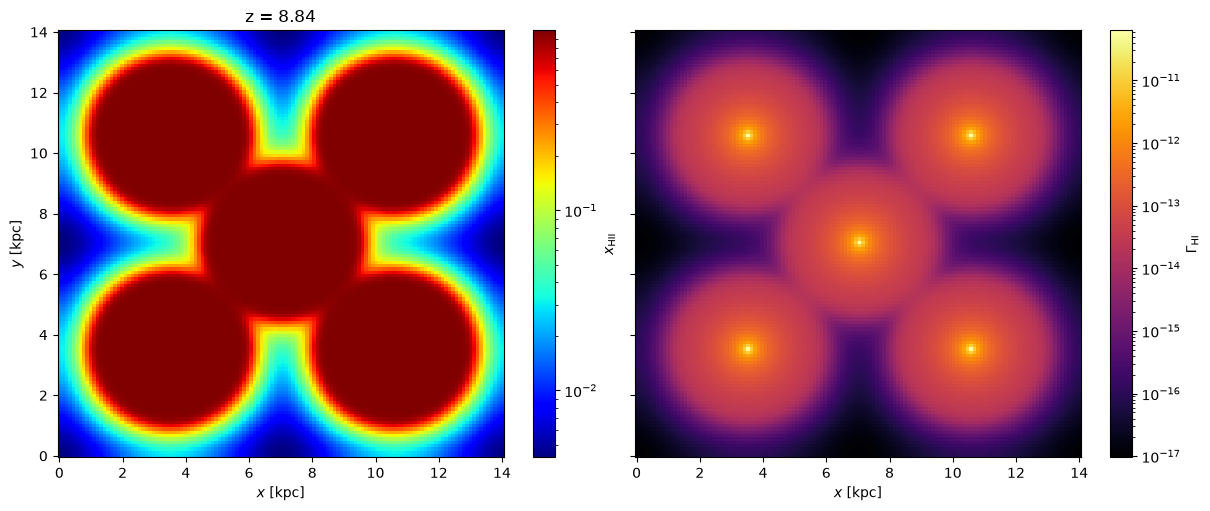

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.402e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 856152 of 2097152 ( 40.825 % ), Relative change in ionfrac:  1.09e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 547336 of 2097152 ( 26.099 % ), Relative change in ionfrac:  5.50e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 9416 of 2097152 ( 0.449 % ), Relative change in ionfrac:  2.18e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  7.08e-05
Multiple source convergence reached after 8 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

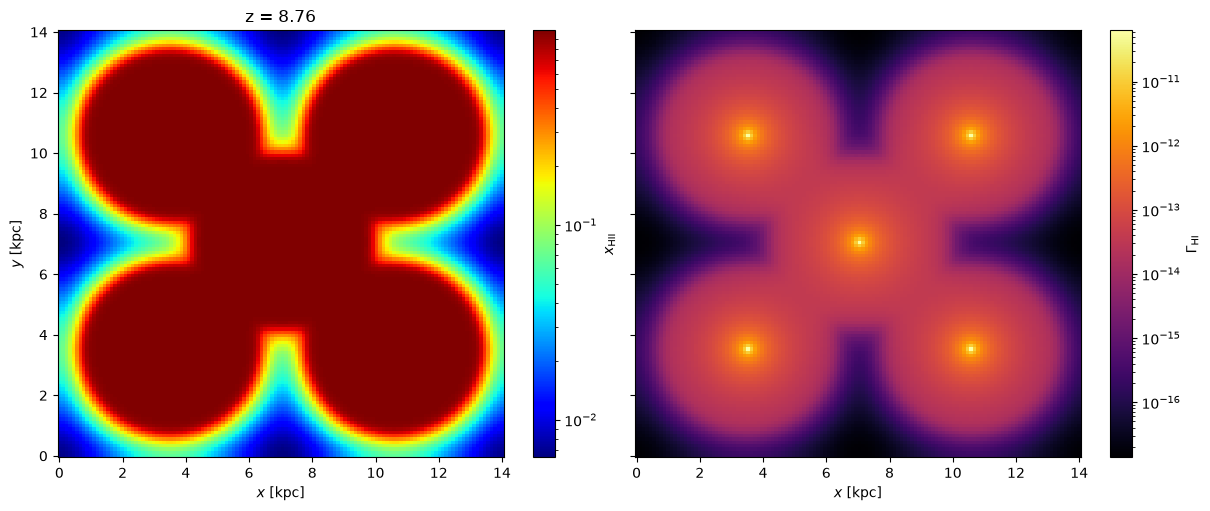

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.834e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 893911 of 2097152 ( 42.625 % ), Relative change in ionfrac:  8.48e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 554474 of 2097152 ( 26.439 % ), Relative change in ionfrac:  4.06e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 24696 of 2097152 ( 1.178 % ), Relative change in ionfrac:  3.53e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 1528 of 2097152 ( 0.073 % ), Relative change in ionfrac:  9.53e-05
Multiple source convergence reached after 7 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

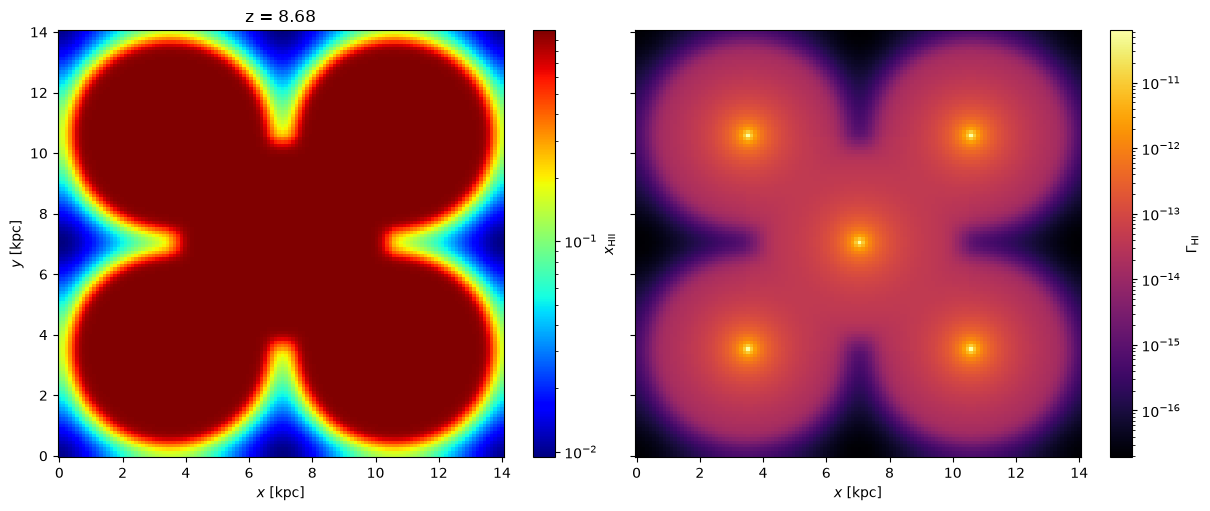

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.245e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 892445 of 2097152 ( 42.555 % ), Relative change in ionfrac:  6.94e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 544820 of 2097152 ( 25.979 % ), Relative change in ionfrac:  3.11e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 12462 of 2097152 ( 0.594 % ), Relative change in ionfrac:  1.83e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 44 of 2097152 ( 0.002 % ), Relative change in ionfrac:  4.42e-05
Multiple source convergence reached after 7 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

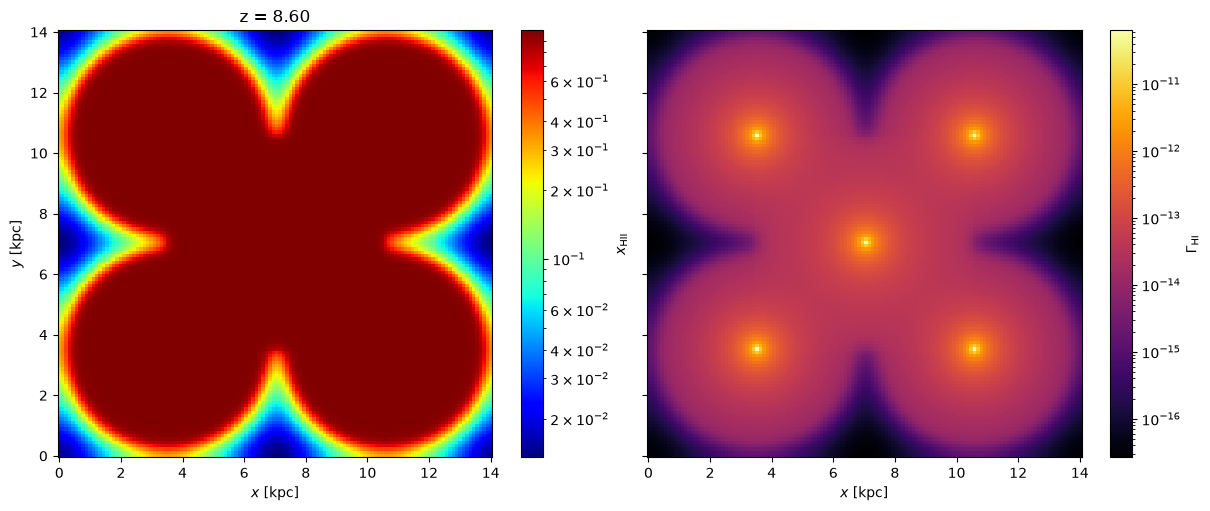

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.634e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 887845 of 2097152 ( 42.336 % ), Relative change in ionfrac:  5.90e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 534098 of 2097152 ( 25.468 % ), Relative change in ionfrac:  2.44e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 3030 of 2097152 ( 0.144 % ), Relative change in ionfrac:  1.03e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.33e-05
Multiple source convergence reached after 7 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

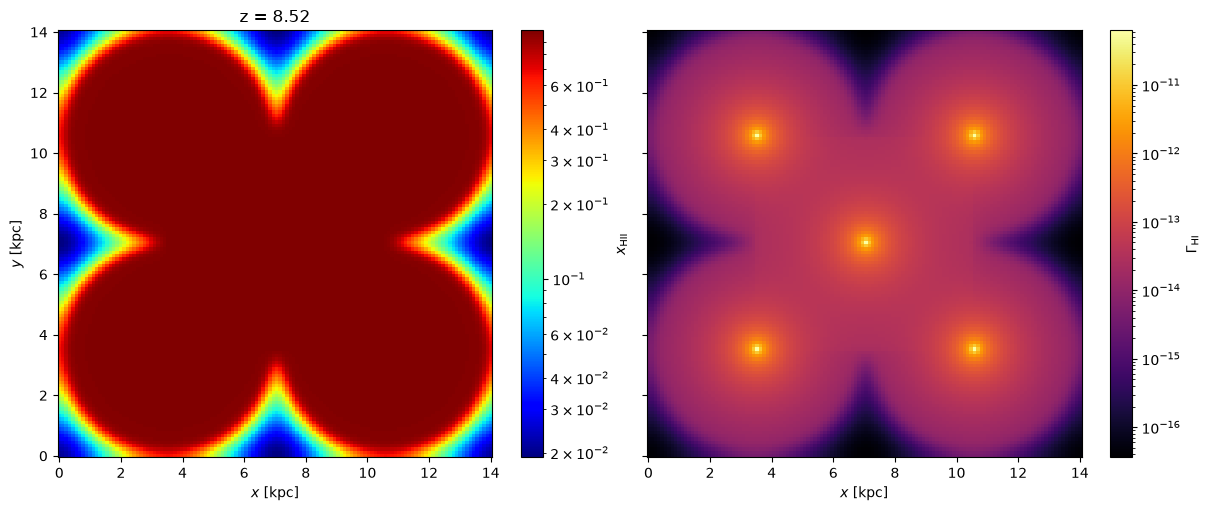

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.999e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 882217 of 2097152 ( 42.067 % ), Relative change in ionfrac:  5.15e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 523804 of 2097152 ( 24.977 % ), Relative change in ionfrac:  1.94e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 29458 of 2097152 ( 1.405 % ), Relative change in ionfrac:  3.00e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 52 of 2097152 ( 0.002 % ), Relative change in ionfrac:  6.63e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

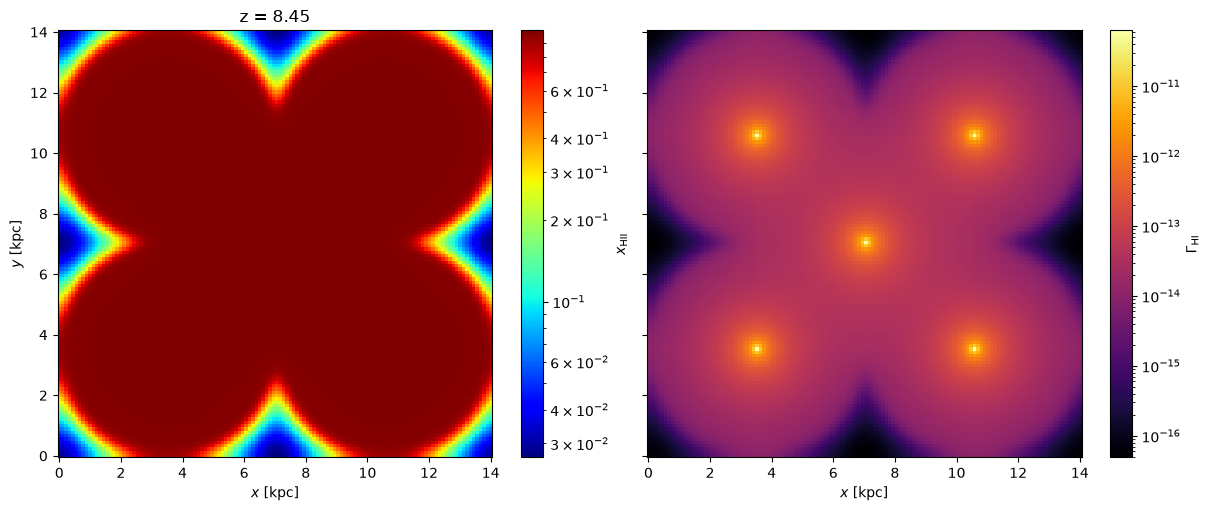

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 3.340e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 876909 of 2097152 ( 41.814 % ), Relative change in ionfrac:  4.59e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 516648 of 2097152 ( 24.636 % ), Relative change in ionfrac:  1.56e-02
Rank=0 is doing Raytracing... 

...

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 16126 of 2097152 ( 0.769 % ), Relative change in ionfrac:  2.12e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.46e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

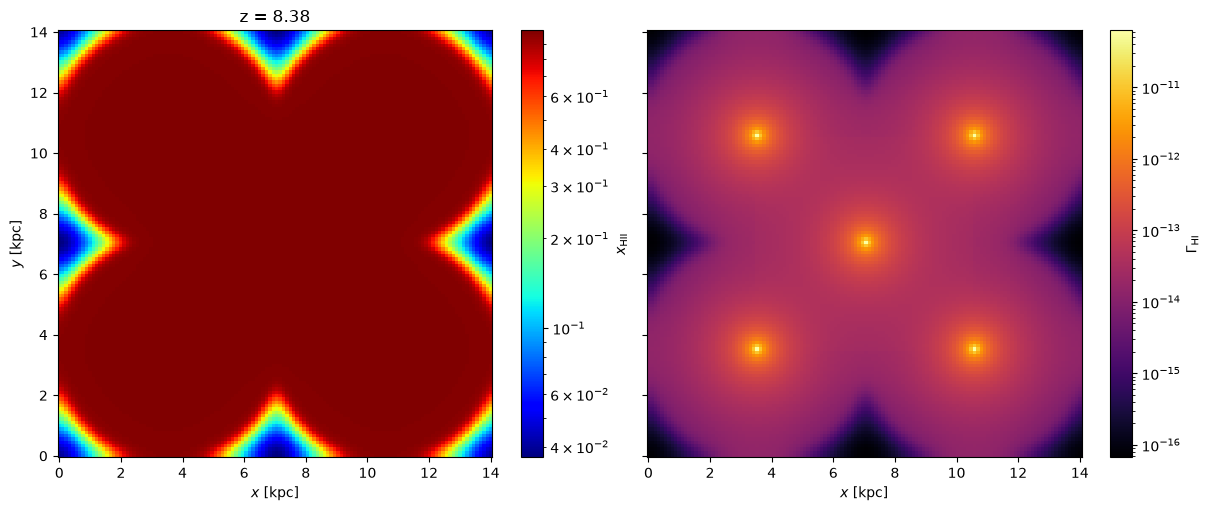

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 3.654e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 870663 of 2097152 ( 41.516 % ), Relative change in ionfrac:  4.16e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 504240 of 2097152 ( 24.044 % ), Relative change in ionfrac:  1.29e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 4876 of 2097152 ( 0.233 % ), Relative change in ionfrac:  1.50e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.93e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

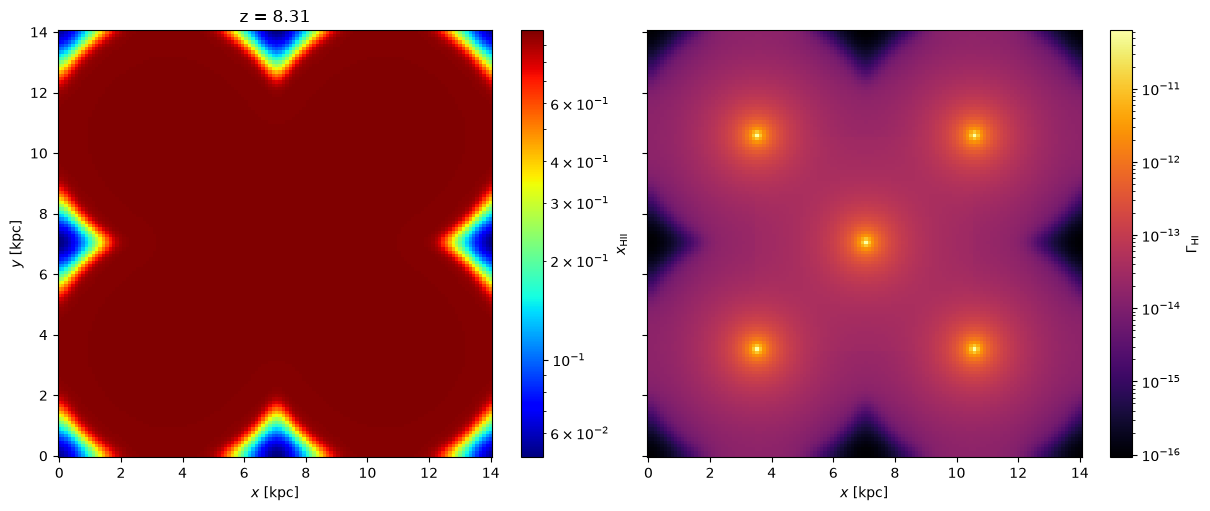

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 3.944e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 860959 of 2097152 ( 41.054 % ), Relative change in ionfrac:  3.82e+00
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 493519 of 2097152 ( 23.533 % ), Relative change in ionfrac:  1.09e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 40 of 2097152 ( 0.002 % ), Relative change in ionfrac:  1.06e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.92e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

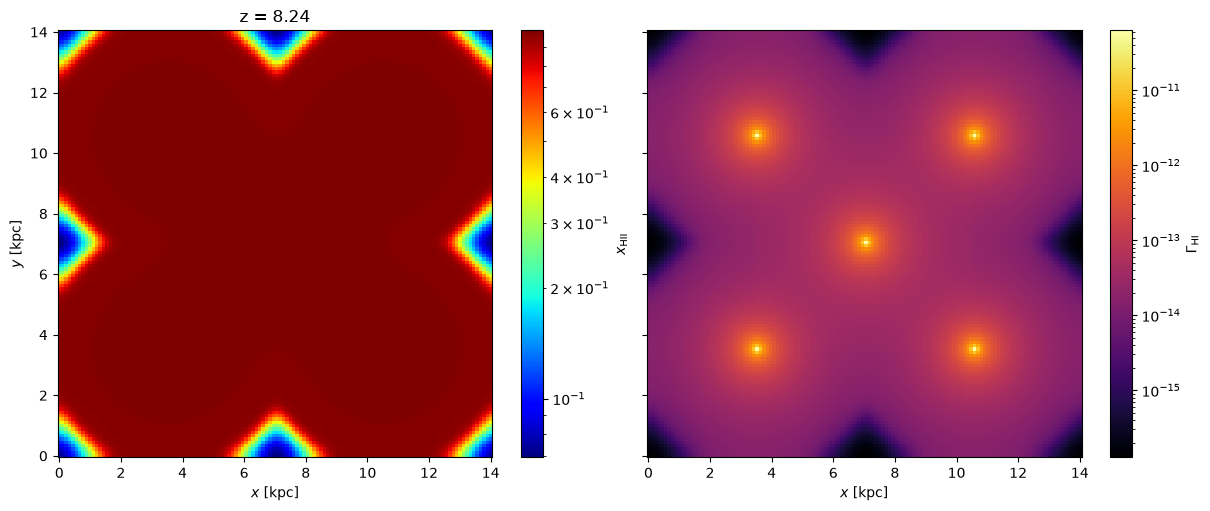

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 4.212e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 844669 of 2097152 ( 40.277 % ), Relative change in ionfrac:  3.54e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 479609 of 2097152 ( 22.870 % ), Relative change in ionfrac:  9.28e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 59034 of 2097152 ( 2.815 % ), Relative change in ionfrac:  4.17e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  7.56e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

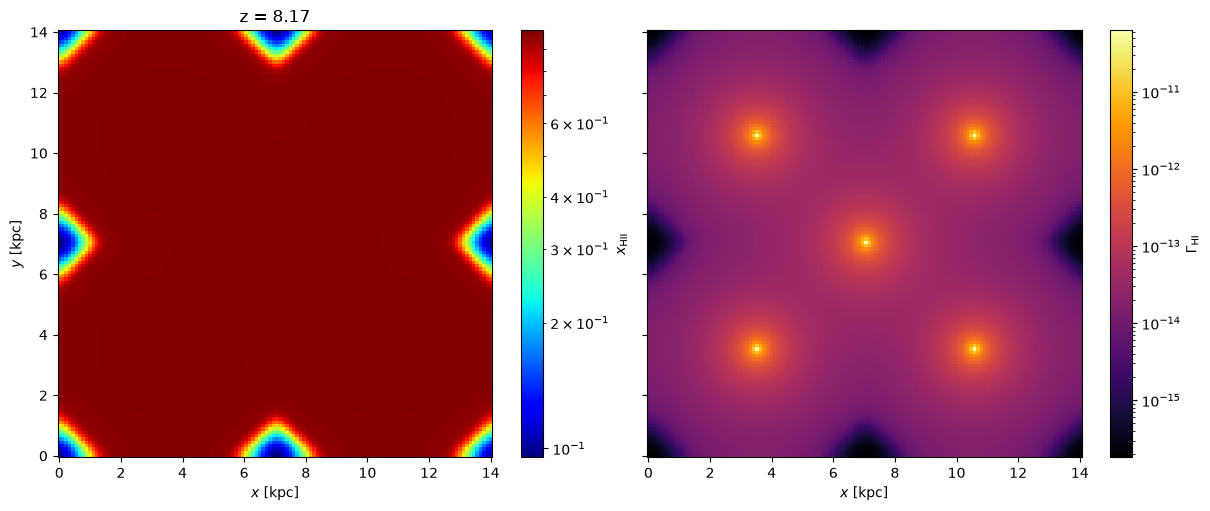

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 4.463e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 823278 of 2097152 ( 39.257 % ), Relative change in ionfrac:  3.30e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 460437 of 2097152 ( 21.955 % ), Relative change in ionfrac:  8.00e-03
Rank=0 is doing Raytracing... 

...

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 43156 of 2097152 ( 2.058 % ), Relative change in ionfrac:  3.22e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.46e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

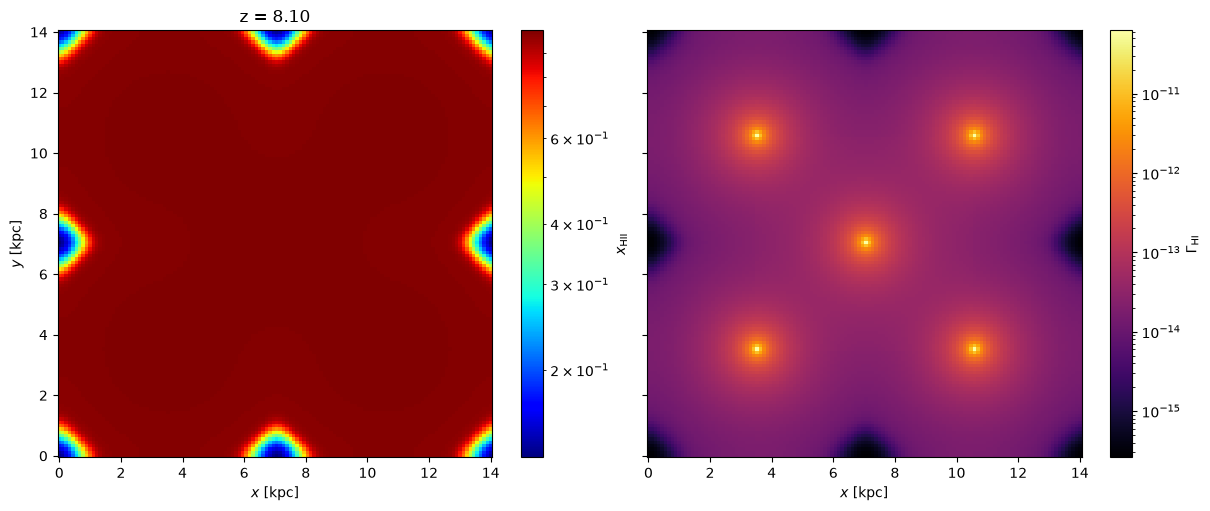

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 4.697e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 801979 of 2097152 ( 38.241 % ), Relative change in ionfrac:  3.10e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 439723 of 2097152 ( 20.968 % ), Relative change in ionfrac:  6.94e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 25850 of 2097152 ( 1.233 % ), Relative change in ionfrac:  2.50e-04
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.00e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

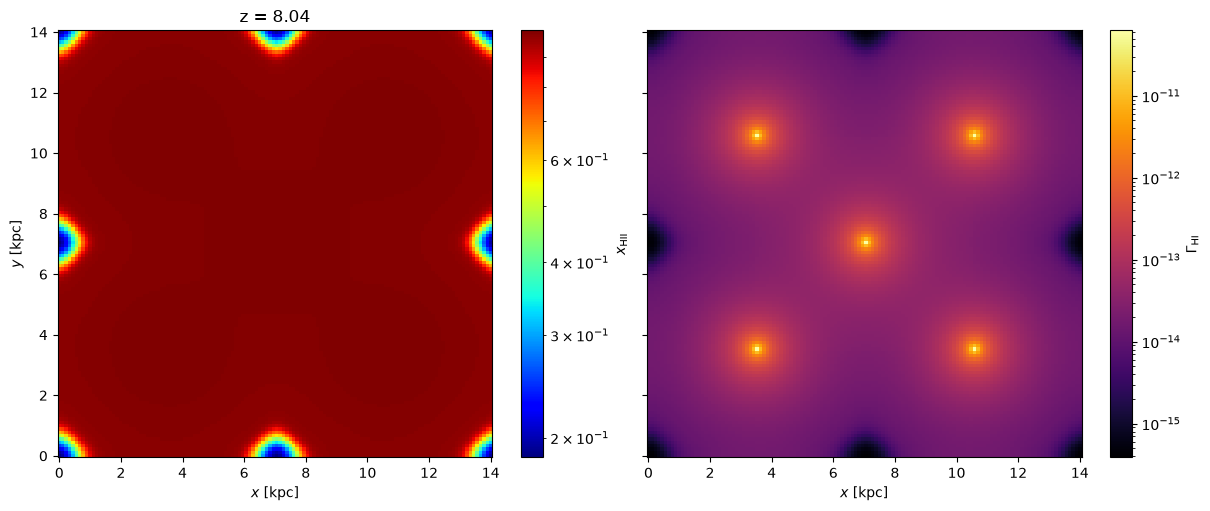

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 4.916e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 782529 of 2097152 ( 37.314 % ), Relative change in ionfrac:  2.93e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 420495 of 2097152 ( 20.051 % ), Relative change in ionfrac:  6.04e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 10760 of 2097152 ( 0.513 % ), Relative change in ionfrac:  1.95e-04
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.99e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

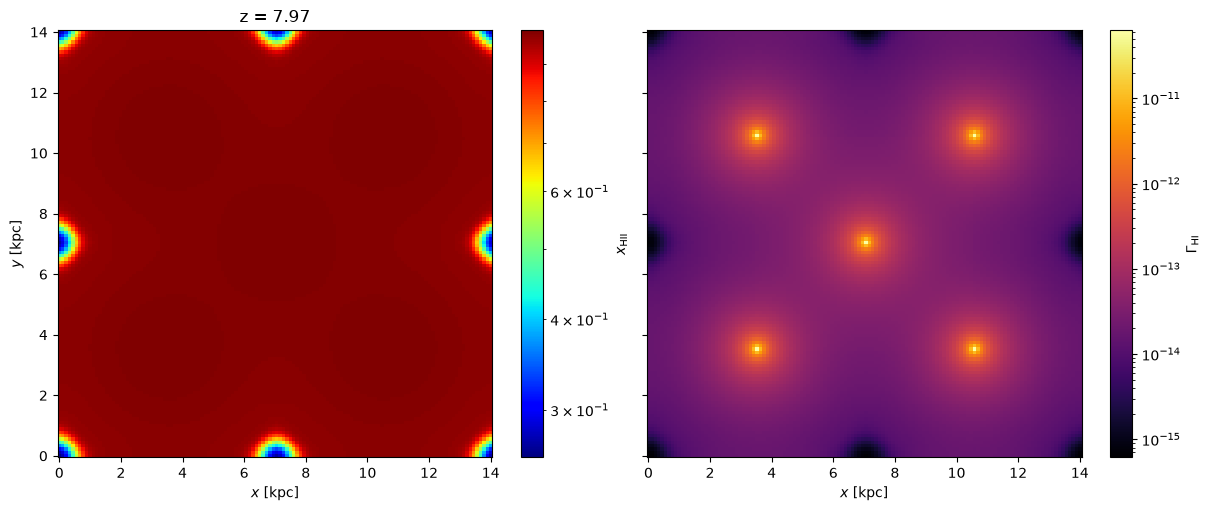

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 5.121e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 764533 of 2097152 ( 36.456 % ), Relative change in ionfrac:  2.79e+00
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 402523 of 2097152 ( 19.194 % ), Relative change in ionfrac:  5.27e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 3826 of 2097152 ( 0.182 % ), Relative change in ionfrac:  1.54e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.28e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

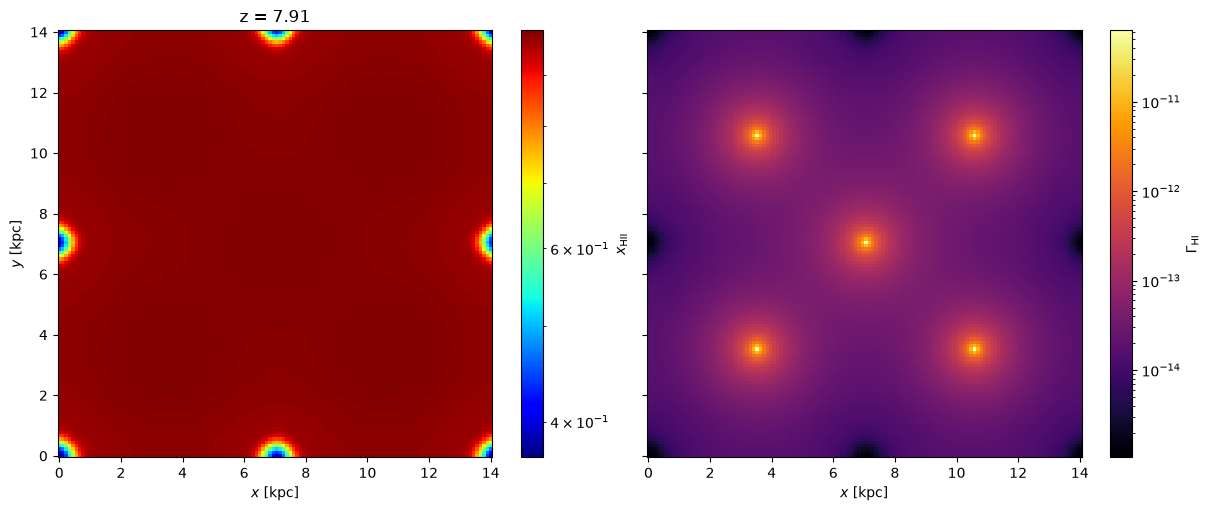

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 5.313e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 748747 of 2097152 ( 35.703 % ), Relative change in ionfrac:  2.66e+00
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.4 s.
Number of non-converged points: 385787 of 2097152 ( 18.396 % ), Relative change in ionfrac:  4.61e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 2529 of 2097152 ( 0.121 % ), Relative change in ionfrac:  1.23e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.79e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

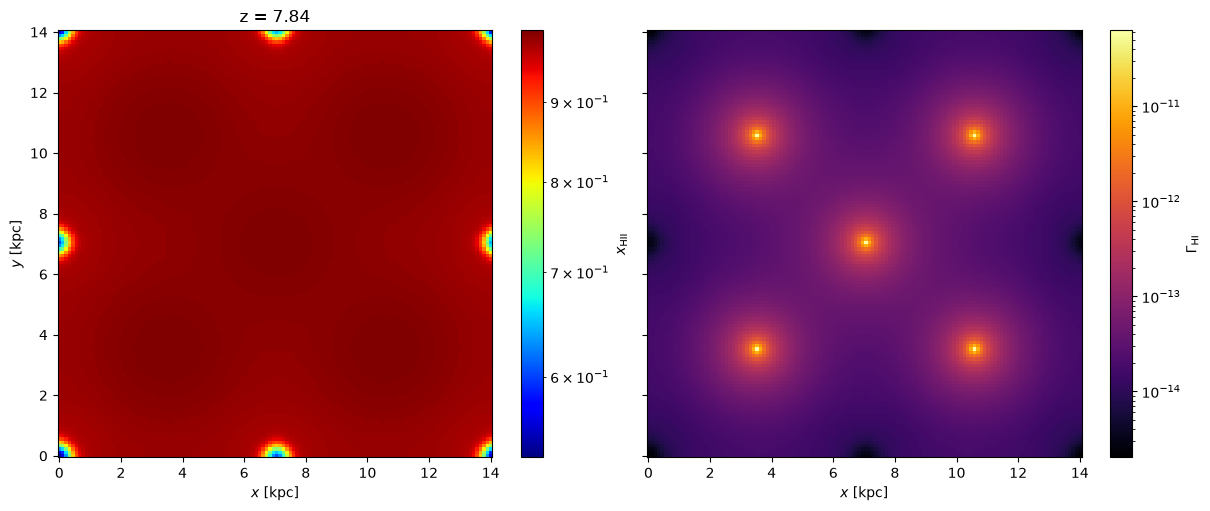

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 2.50e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 5.492e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 734473 of 2097152 ( 35.022 % ), Relative change in ionfrac:  2.55e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 370105 of 2097152 ( 17.648 % ), Relative change in ionfrac:  4.03e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 1833 of 2097152 ( 0.087 % ), Relative change in ionfrac:  9.86e-05
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.43e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

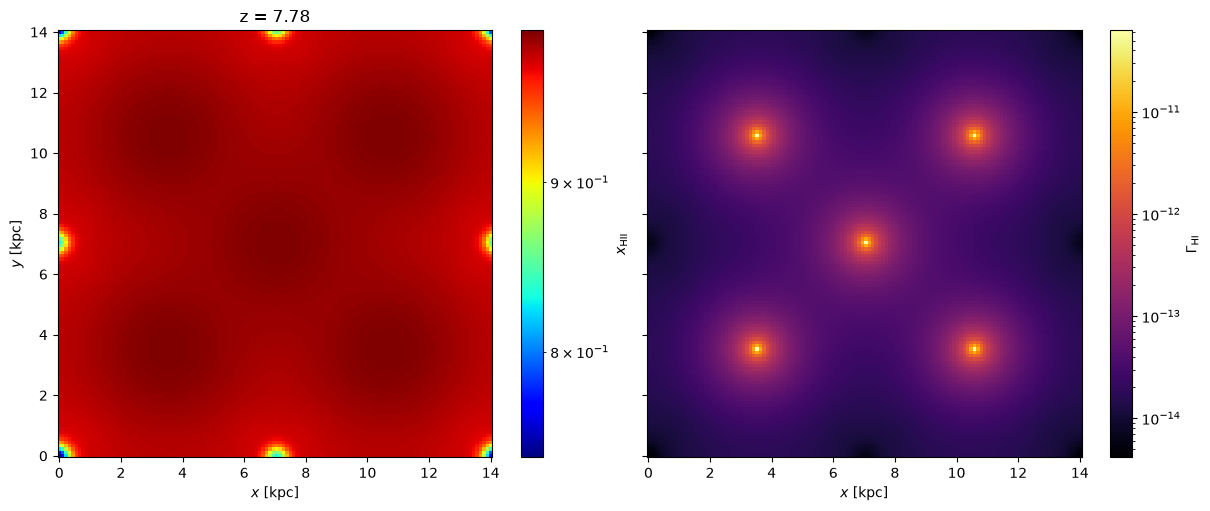

<Figure size 640x480 with 0 Axes>

In [23]:
sim_a, srcpos_a, srcflux_a, timer_a = run_multi_sources('validation/parameters_mult_equal.yml', 'validation/src_mult_equal.txt')

Let's look at the wall clock time at each time step of our simulation.

In [24]:
print(timer_a.summary)


--- TIMER SUMMARY ---
 step 1: 9.34s - t=0
 step 2: 6.92s - t=1
 step 3: 7.83s - t=0
 step 4: 6.99s - t=1
 step 5: 6.36s - t=0
 step 6: 6.25s - t=1
 step 7: 6.42s - t=0
 step 8: 5.57s - t=1
 step 9: 5.60s - t=0
 step 10: 5.51s - t=1
 step 11: 5.62s - t=0
 step 12: 4.78s - t=1
 step 13: 4.75s - t=0
 step 14: 4.67s - t=1
 step 15: 4.75s - t=0
 step 16: 4.82s - t=1
 step 17: 4.70s - t=0
 step 18: 4.63s - t=1
Elapsed time: 1m 45.93s 


Cell-by-cell comparison with a CPU-raytracing run of the same case (`test_results_mult_equal_cpu/`, produced by `validation/jobs/dardel_multi_sources_cpu.sh`). Skipped if that run is not available.

In [25]:
import os

ref_dir, gpu_dir = './test_results_mult_equal_cpu/', sim_a.results_basename
if not os.path.isdir(ref_dir):
    print(f'No CPU reference in {ref_dir}, skipping comparison.')
else:
    print(f"{'z':>6} {'<xHII> GPU':>11} {'<xHII> CPU':>11} {'max|dx|':>9} {'mean|dx|':>9} {'median rel. dGamma':>19}")
    for fname in sorted(f for f in os.listdir(ref_dir) if f.startswith('xfrac_') and f.endswith('.npy')):
        z = fname[len('xfrac_'):-len('.npy')]
        x_gpu, x_cpu = np.load(gpu_dir + fname), np.load(ref_dir + fname)
        g_gpu, g_cpu = np.load(f'{gpu_dir}IonRates_{z}.npy'), np.load(f'{ref_dir}IonRates_{z}.npy')
        dx = np.abs(x_gpu - x_cpu)
        lit = g_cpu > 0
        rel_dg = np.abs(g_gpu[lit] - g_cpu[lit]) / g_cpu[lit] if lit.any() else np.array([np.nan])
        print(f'{z:>6} {x_gpu.mean():11.4f} {x_cpu.mean():11.4f} {dx.max():9.2e} {dx.mean():9.2e} {np.median(rel_dg):19.2e}')

     z  <xHII> GPU  <xHII> CPU   max|dx|  mean|dx|  median rel. dGamma


 7.723      0.5660      0.5660  3.81e-01  1.62e-02            1.09e-01


 7.845      0.5313      0.5313  3.89e-01  1.67e-02            1.17e-01


 7.971      0.4916      0.4916  3.94e-01  1.71e-02            1.25e-01


 8.102      0.4463      0.4463  3.95e-01  1.74e-02            1.32e-01


 8.238      0.3944      0.3944  3.91e-01  1.76e-02            1.37e-01


 8.378      0.3340      0.3340  3.75e-01  1.78e-02            1.39e-01


 8.525      0.2634      0.2634  3.54e-01  1.72e-02            1.37e-01


 8.677      0.1834      0.1834  3.57e-01  1.50e-02            1.32e-01


 8.835      0.0953      0.0953  3.72e-01  1.10e-02            1.20e-01
 9.000      0.0012      0.0012  0.00e+00  0.00e+00                 nan


### 3b. Single source brighter than the others

The source at (96, 32, 64) keeps the 3a flux of $5\times10^{48}$ photons/s, while the other four are reduced to a quarter, $1.25\times10^{48}$ photons/s: its HII region should be the largest, and the other four smaller than in 3a. At the source cells, the photoionization rate should stay about the same as in 3a for the bright source and drop to about a quarter for the other four. The CPU raytracer cannot be used as a reference here (see the note above).


                 _________   ____            
    ____  __  __/ ____/__ \ / __ \____ ___  __
   / __ \/ / / / /    __/ // /_/ / __ `/ / / /
  / /_/ / /_/ / /___ / __// _, _/ /_/ / /_/ /
 / .___/\__, /\____//____/_/ |_|\__,_/\__, /
/_/    /____/                        /____/

Welcome! Mesh size is N = 128.
Simulation Box size (comoving Mpc): 1.400e-02
Cosmology is off.
Using power-law opacity with 10000 table points between tau=10^(-20) and tau=10^(4)
Using Black-Body sources with effective temperature T = 5.0e+04 K and Radius  1.437e-11 rsun
Spectrum Frequency Range: 3.288e+15 to 1.316e+17 Hz
This is Energy:           1.360e+01 to 5.442e+02 eV
Integrating photoionization rates tables...


INFO: No heating rates
Successfully copied radiation tables to GPU memory.

---- Calculated Clumping Factor (constant model):
 min, mean and max clumping : 1.000e+00  1.000e+00  1.000e+00

---- Calculated Mean-Free Path (constant model):
Maximum comoving distance for photons from source mfp = 15.00 cMpc (constant model).
 This corresponds to 137142.857 grid cells.

Using ASORA Raytracing ( q_max = 192 )
Running in non-MPI (single-GPU/CPU) mode
Starting simulation... 


Running: "C2Ray Test"
[9.00000003 8.83505707 8.6767426  8.52464015 8.37836826 8.23757704
 8.10194471 7.97117508 7.84499469 7.72315089]


Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.200e-03
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 109432 of 2097152 ( 5.218 % ), Relative change in ionfrac:  5.92e+02
Rank=0 is doing Raytracing... 

...

took  0.3 s.
Number of non-converged points: 19988 of 2097152 ( 0.953 % ), Relative change in ionfrac:  3.09e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 6836 of 2097152 ( 0.326 % ), Relative change in ionfrac:  8.69e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.18e-04
Multiple source convergence reached after 12 ray-tracing iterations.


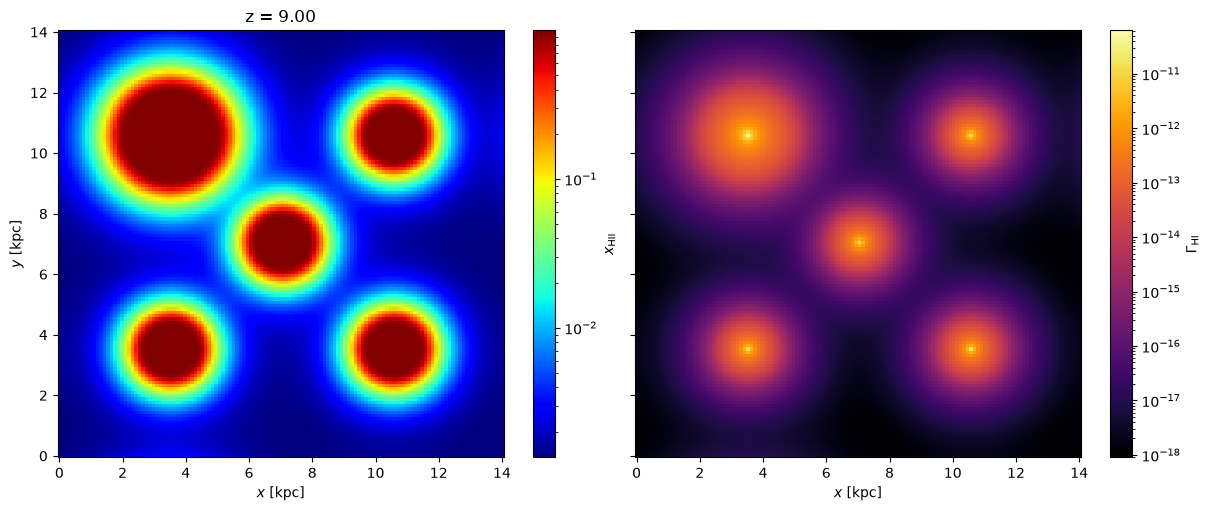

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.024e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 341657 of 2097152 ( 16.291 % ), Relative change in ionfrac:  6.49e+01
Rank=0 is doing Raytracing... 

took 0.39s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 207527 of 2097152 ( 9.896 % ), Relative change in ionfrac:  1.32e-01
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 8926 of 2097152 ( 0.426 % ), Relative change in ionfrac:  6.97e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.58e-04
Multiple source convergence reached after 8 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

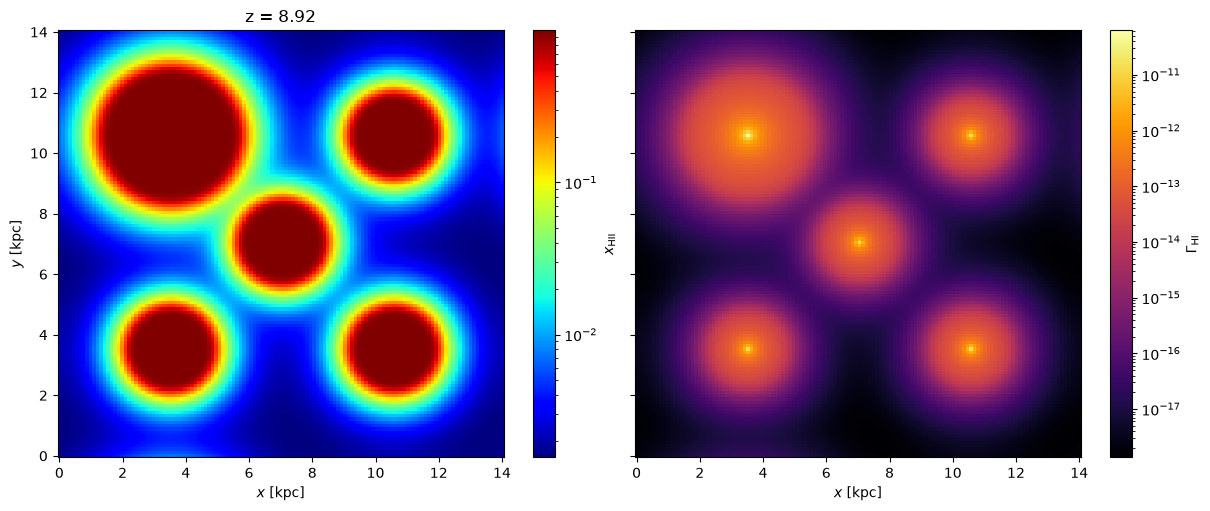

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 3.887e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 427320 of 2097152 ( 20.376 % ), Relative change in ionfrac:  3.86e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 239439 of 2097152 ( 11.417 % ), Relative change in ionfrac:  7.61e-02
Rank=0 is doing Raytracing... 

...

took 0.39s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 36192 of 2097152 ( 1.726 % ), Relative change in ionfrac:  2.17e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.71e-04
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

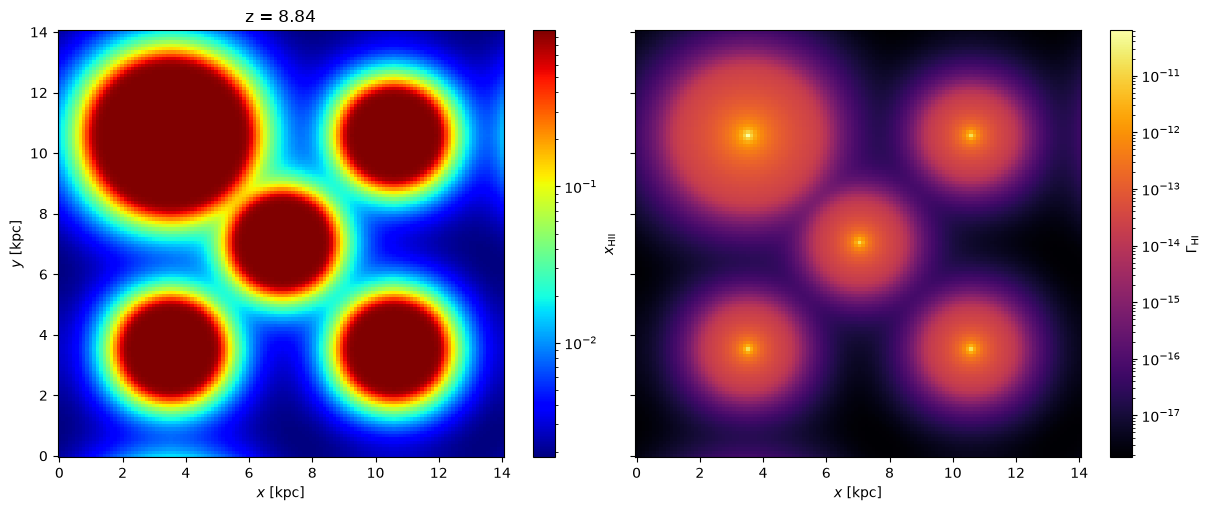

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 5.692e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 487039 of 2097152 ( 23.224 % ), Relative change in ionfrac:  2.79e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 260460 of 2097152 ( 12.420 % ), Relative change in ionfrac:  5.03e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 19897 of 2097152 ( 0.949 % ), Relative change in ionfrac:  7.36e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.30e-04
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

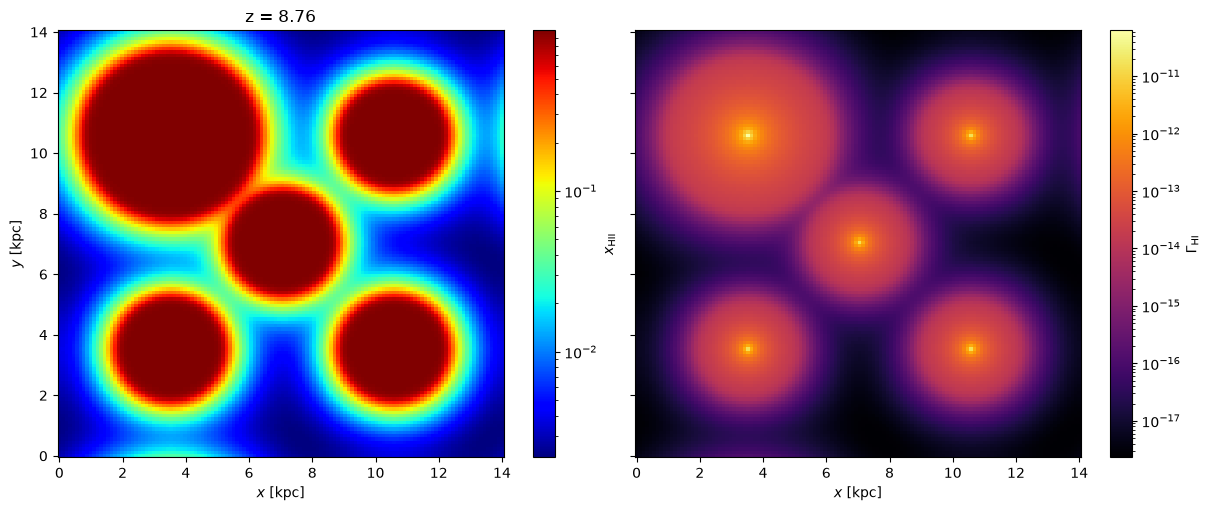

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 7.439e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 531263 of 2097152 ( 25.333 % ), Relative change in ionfrac:  2.20e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 276059 of 2097152 ( 13.164 % ), Relative change in ionfrac:  3.57e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 520 of 2097152 ( 0.025 % ), Relative change in ionfrac:  3.21e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.12e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

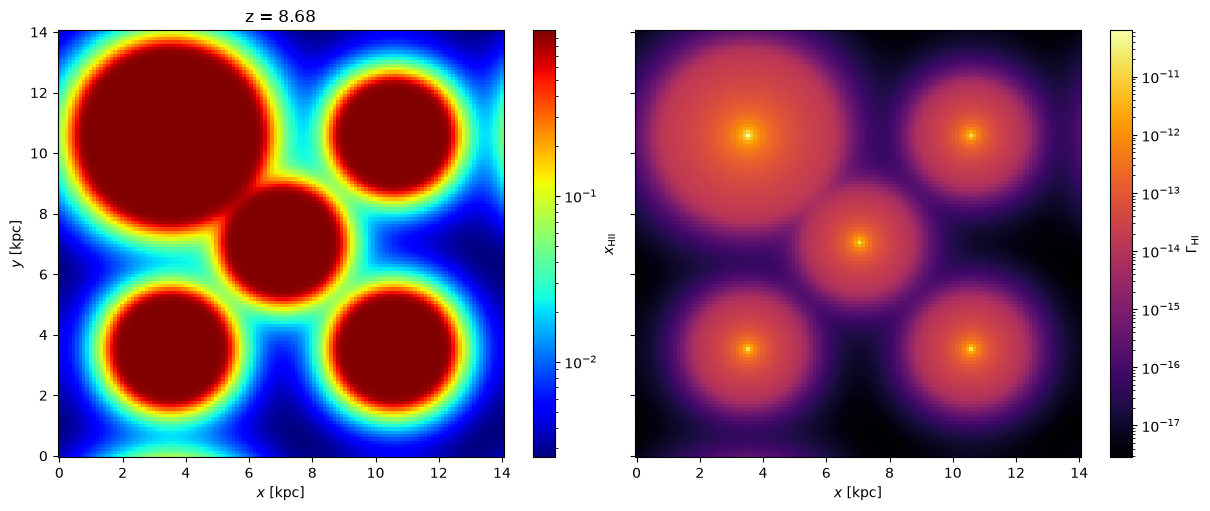

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 9.127e-02
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 565919 of 2097152 ( 26.985 % ), Relative change in ionfrac:  1.82e+01
Rank=0 is doing Raytracing... 

took 0.39s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 289175 of 2097152 ( 13.789 % ), Relative change in ionfrac:  2.68e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 424 of 2097152 ( 0.020 % ), Relative change in ionfrac:  1.79e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.92e-05
Multiple source convergence reached after 6 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

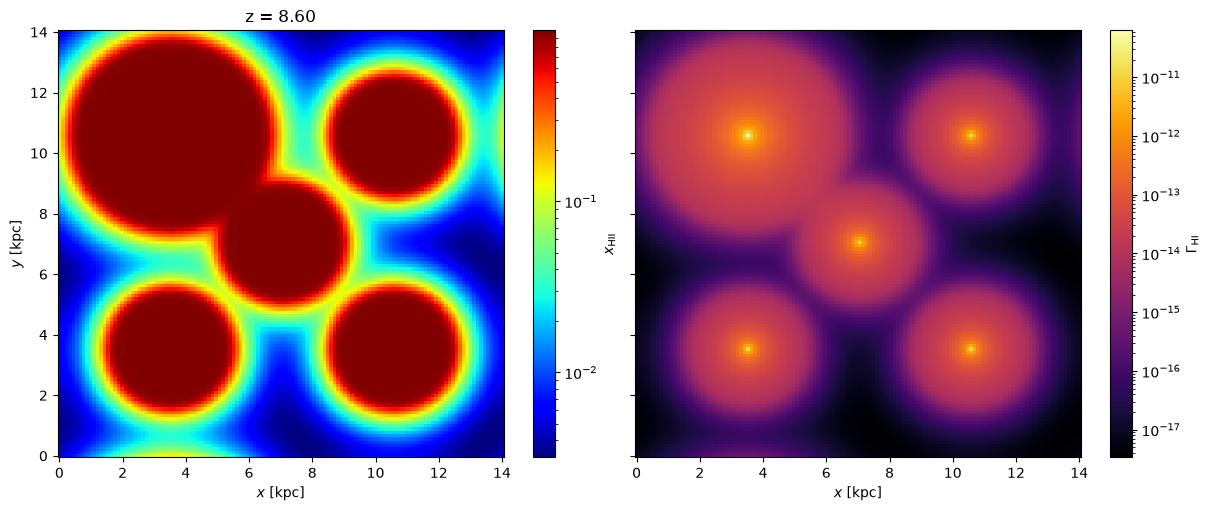

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.076e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 595483 of 2097152 ( 28.395 % ), Relative change in ionfrac:  1.56e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 298705 of 2097152 ( 14.243 % ), Relative change in ionfrac:  2.08e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 26155 of 2097152 ( 1.247 % ), Relative change in ionfrac:  6.85e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.04e-04
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

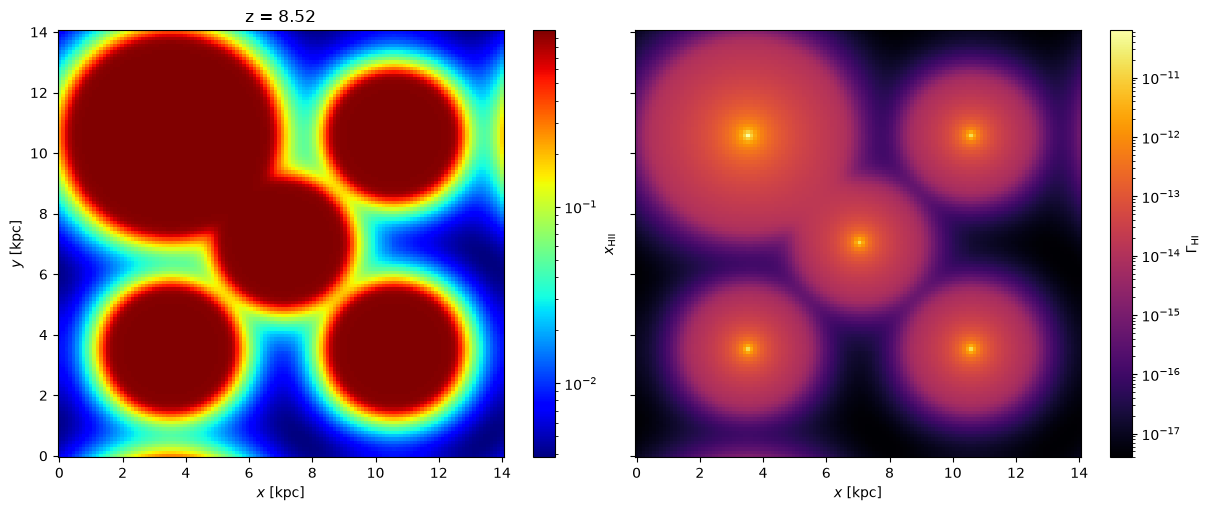

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.233e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 618601 of 2097152 ( 29.497 % ), Relative change in ionfrac:  1.37e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 304969 of 2097152 ( 14.542 % ), Relative change in ionfrac:  1.66e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 3602 of 2097152 ( 0.172 % ), Relative change in ionfrac:  4.43e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  6.04e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

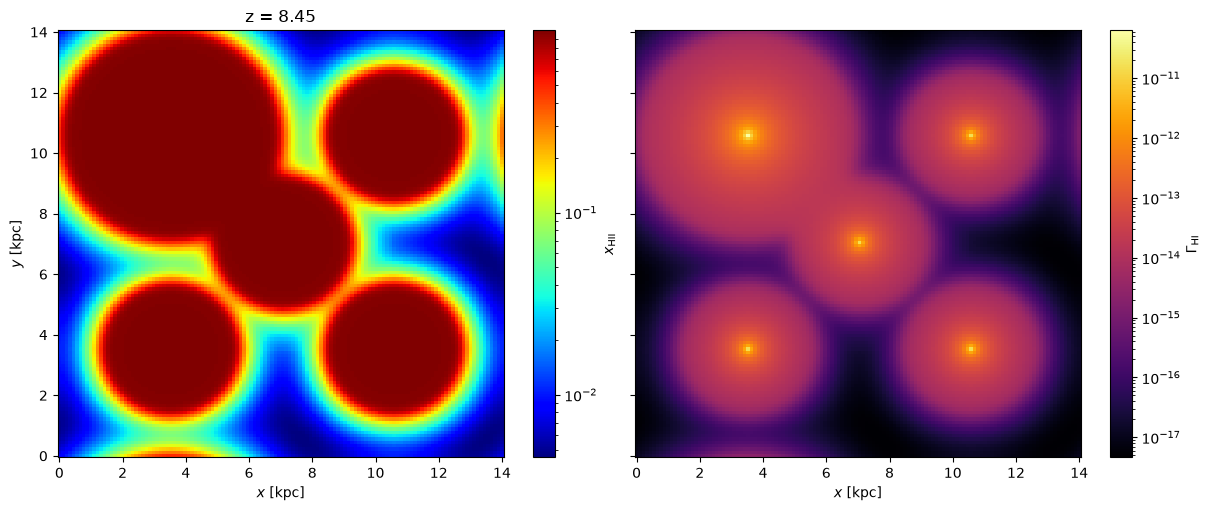

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.385e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 636595 of 2097152 ( 30.355 % ), Relative change in ionfrac:  1.23e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 306787 of 2097152 ( 14.629 % ), Relative change in ionfrac:  1.35e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 2210 of 2097152 ( 0.105 % ), Relative change in ionfrac:  2.97e-04
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  3.67e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

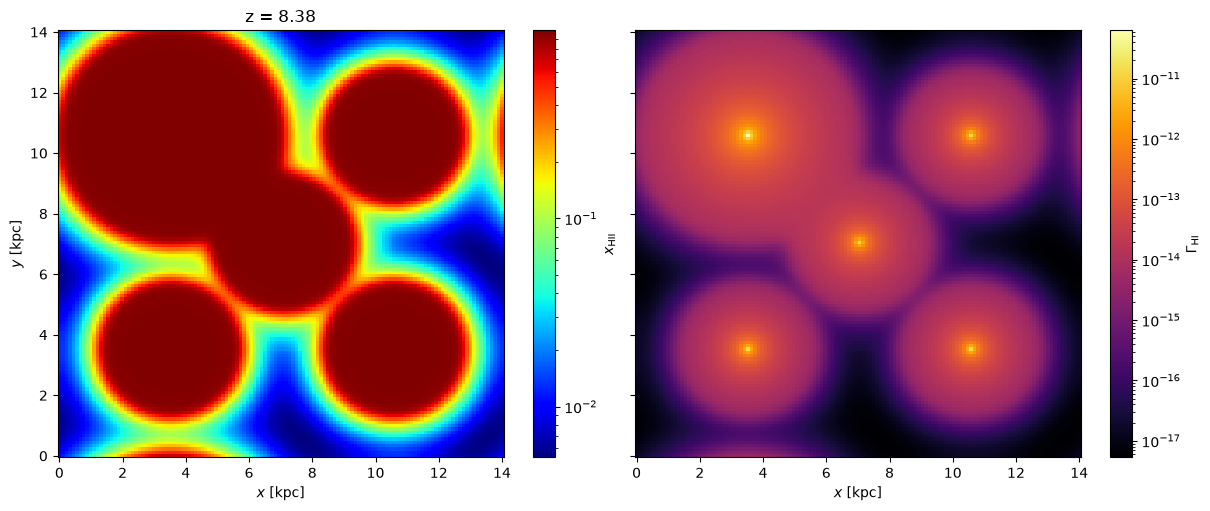

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.532e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 651963 of 2097152 ( 31.088 % ), Relative change in ionfrac:  1.11e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 306266 of 2097152 ( 14.604 % ), Relative change in ionfrac:  1.11e-02
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 1102 of 2097152 ( 0.053 % ), Relative change in ionfrac:  2.06e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  2.36e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

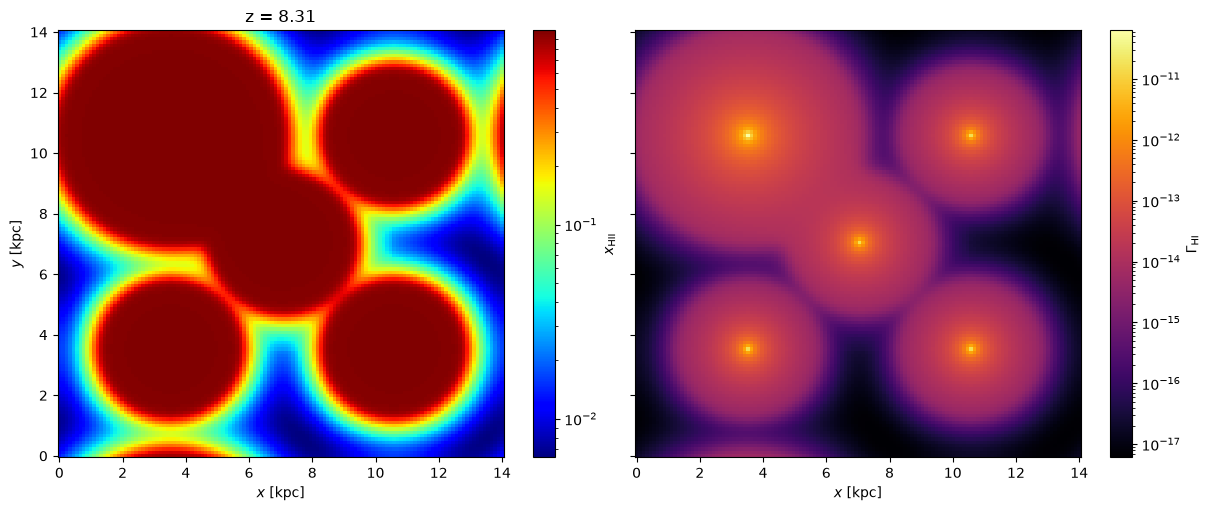

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.673e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 664242 of 2097152 ( 31.674 % ), Relative change in ionfrac:  1.02e+01
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 304633 of 2097152 ( 14.526 % ), Relative change in ionfrac:  9.27e-03
Rank=0 is doing Raytracing... 

...

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 76 of 2097152 ( 0.004 % ), Relative change in ionfrac:  1.51e-04
Rank=0 is doing Raytracing... 

took 0.39s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.66e-05
Multiple source convergence reached after 5 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

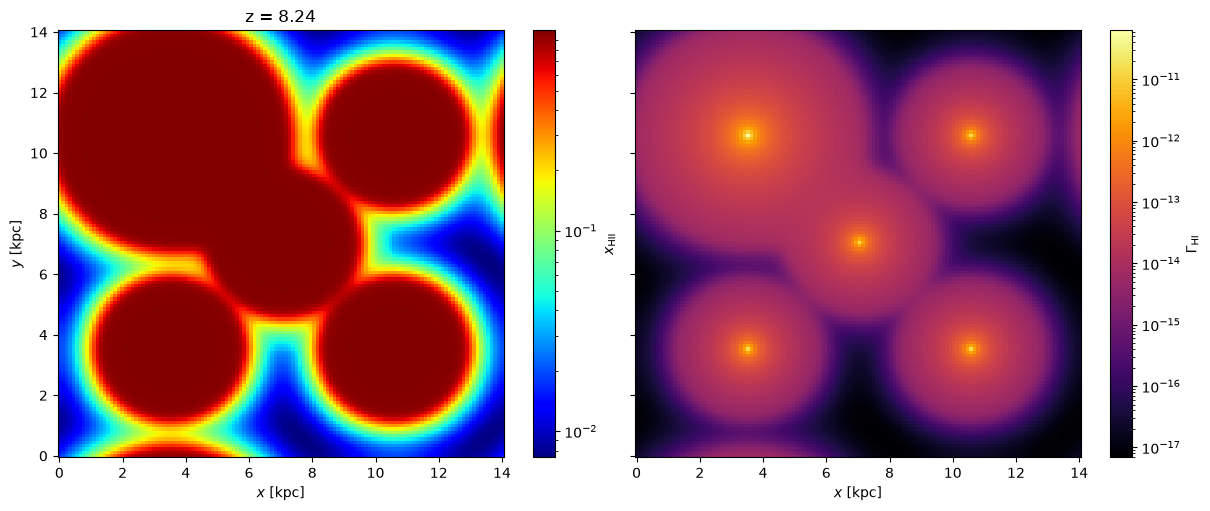

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.809e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 674670 of 2097152 ( 32.171 % ), Relative change in ionfrac:  9.40e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 302470 of 2097152 ( 14.423 % ), Relative change in ionfrac:  7.85e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 69143 of 2097152 ( 3.297 % ), Relative change in ionfrac:  1.01e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  1.16e-04
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

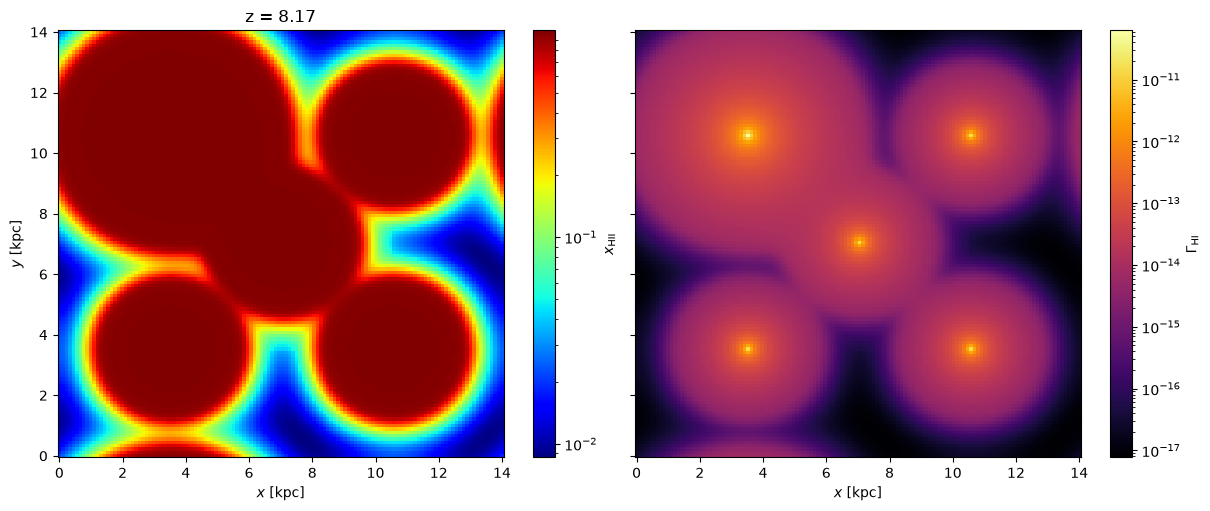

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 1.940e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 683728 of 2097152 ( 32.603 % ), Relative change in ionfrac:  8.76e+00
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 299555 of 2097152 ( 14.284 % ), Relative change in ionfrac:  6.71e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 56716 of 2097152 ( 2.704 % ), Relative change in ionfrac:  8.22e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  9.30e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

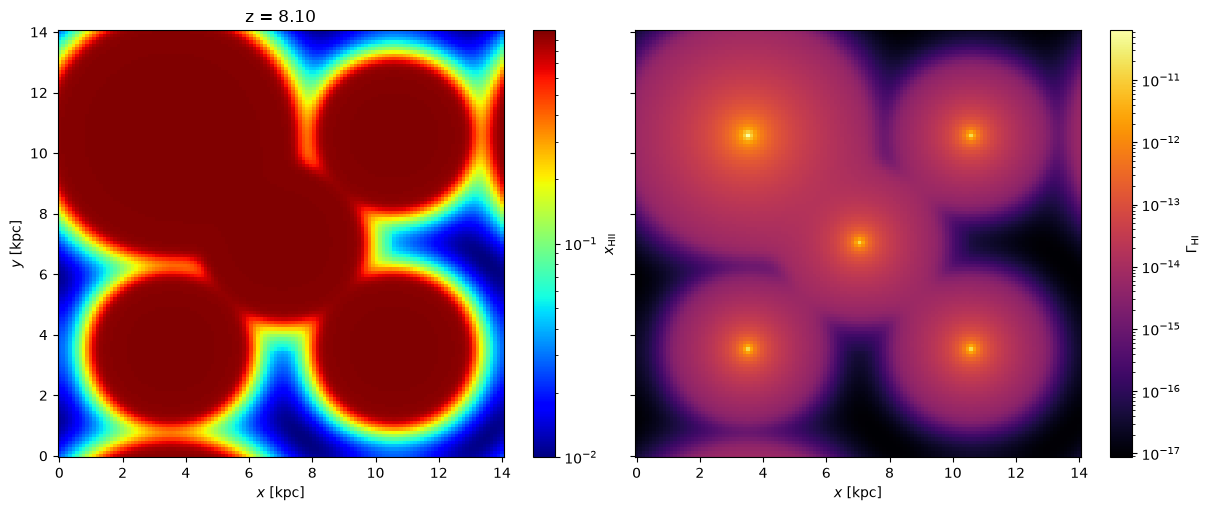

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.065e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 692086 of 2097152 ( 33.001 % ), Relative change in ionfrac:  8.21e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 294958 of 2097152 ( 14.065 % ), Relative change in ionfrac:  5.78e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 38335 of 2097152 ( 1.828 % ), Relative change in ionfrac:  6.77e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  7.54e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

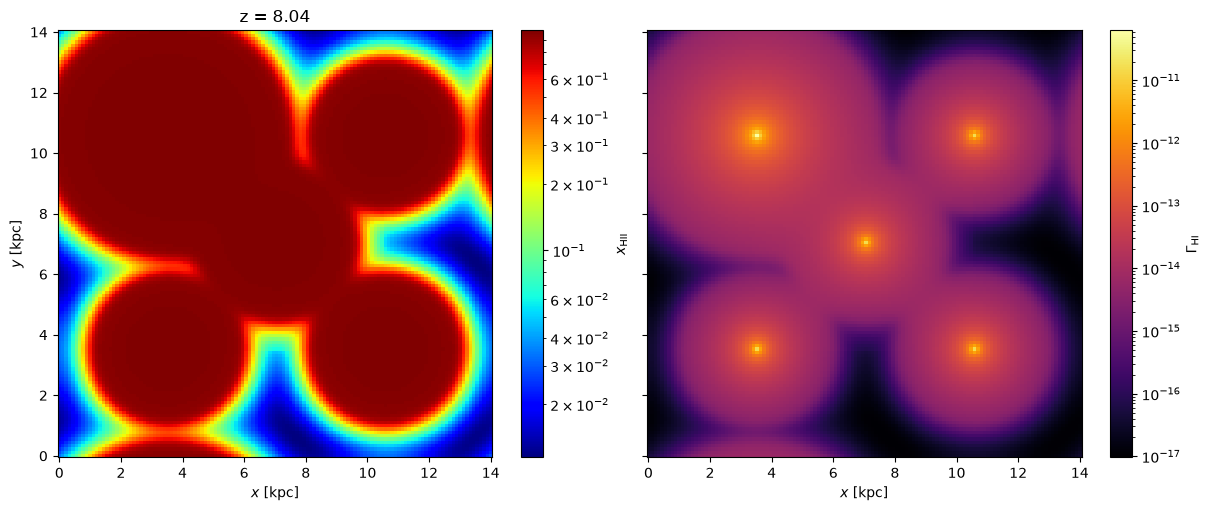

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.186e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 699211 of 2097152 ( 33.341 % ), Relative change in ionfrac:  7.74e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 289029 of 2097152 ( 13.782 % ), Relative change in ionfrac:  5.01e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 20328 of 2097152 ( 0.969 % ), Relative change in ionfrac:  5.61e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  6.15e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

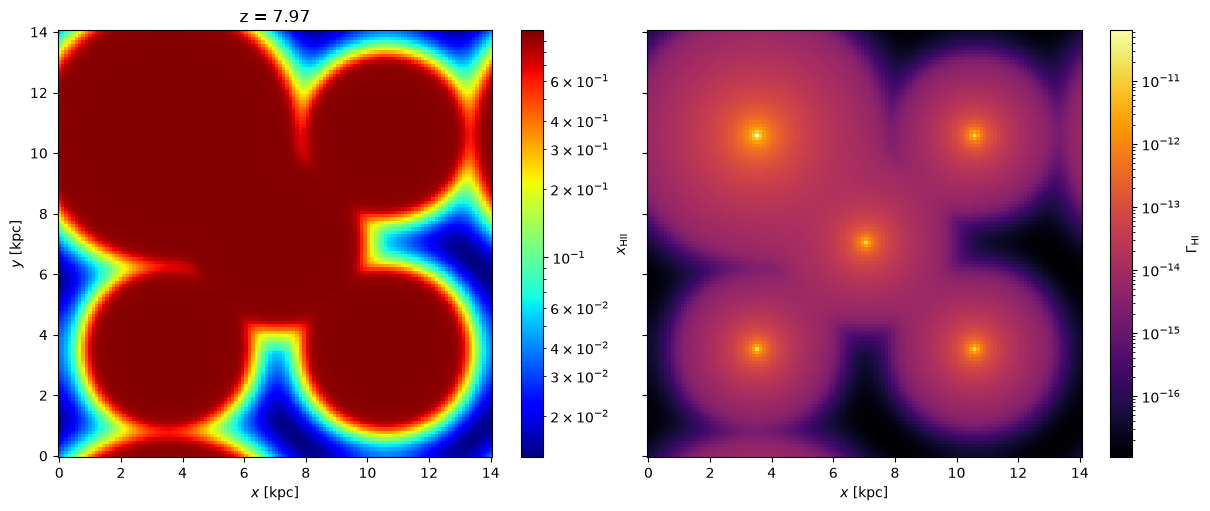

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.302e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 704686 of 2097152 ( 33.602 % ), Relative change in ionfrac:  7.33e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 282681 of 2097152 ( 13.479 % ), Relative change in ionfrac:  4.36e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 14752 of 2097152 ( 0.703 % ), Relative change in ionfrac:  4.69e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  5.09e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

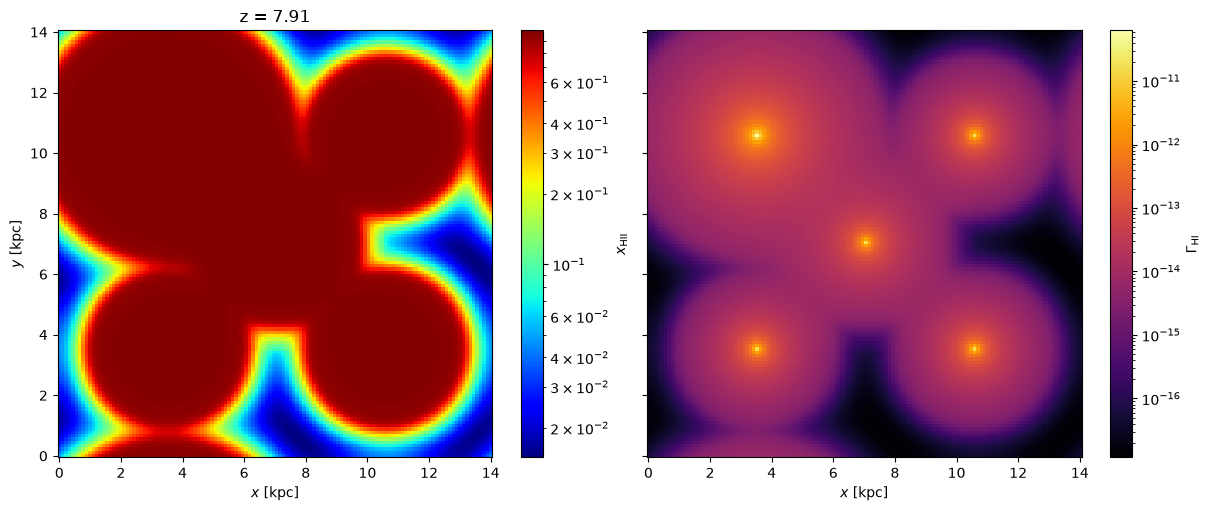

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.413e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 709125 of 2097152 ( 33.814 % ), Relative change in ionfrac:  6.97e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 275897 of 2097152 ( 13.156 % ), Relative change in ionfrac:  3.81e-03
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 10634 of 2097152 ( 0.507 % ), Relative change in ionfrac:  3.95e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  4.25e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

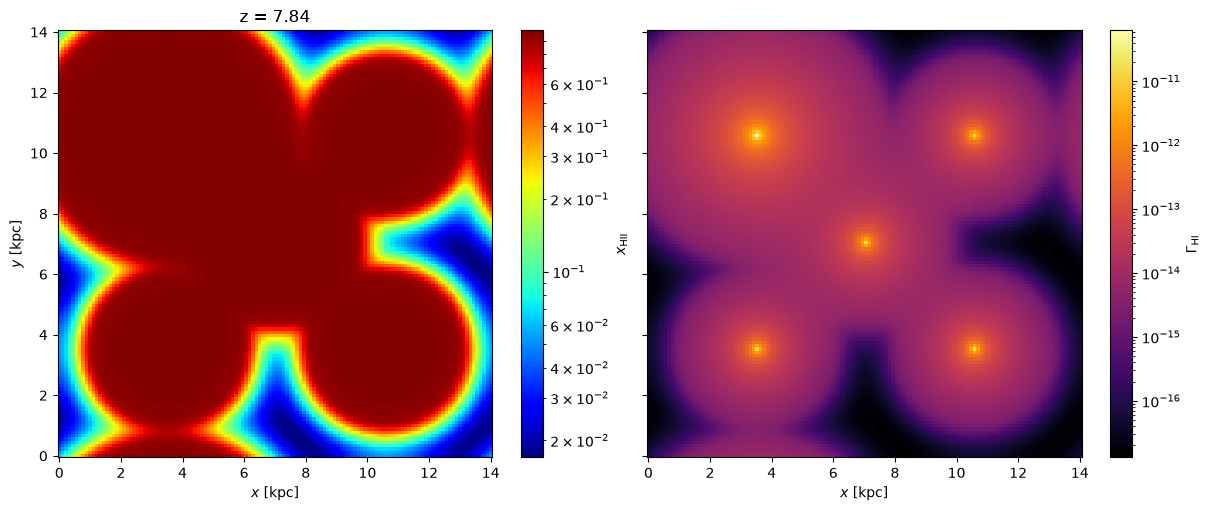

Rank 0 copied source data to device.
Calling evolve3D...
dr [Mpc]: 1.094e-04
dt [years]: 5.000e+06
Running on 5 source(s), total normalized ionizing flux: 1.00e+01
Mean density (cgs): 1.000e-03, Mean ionized fraction: 2.519e-01
Convergence Criterion (Number of points):  1.33333

Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 711700 of 2097152 ( 33.937 % ), Relative change in ionfrac:  6.66e+00
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 267664 of 2097152 ( 12.763 % ), Relative change in ionfrac:  3.35e-03
Rank=0 is doing Raytracing... 

took 0.41s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 6778 of 2097152 ( 0.323 % ), Relative change in ionfrac:  3.35e-04
Rank=0 is doing Raytracing... 

took 0.40s.
Doing Chemistry... 

took  0.3 s.
Number of non-converged points: 0 of 2097152 ( 0.000 % ), Relative change in ionfrac:  3.55e-05
Multiple source convergence reached after 4 ray-tracing iterations.


<Figure size 640x480 with 0 Axes>

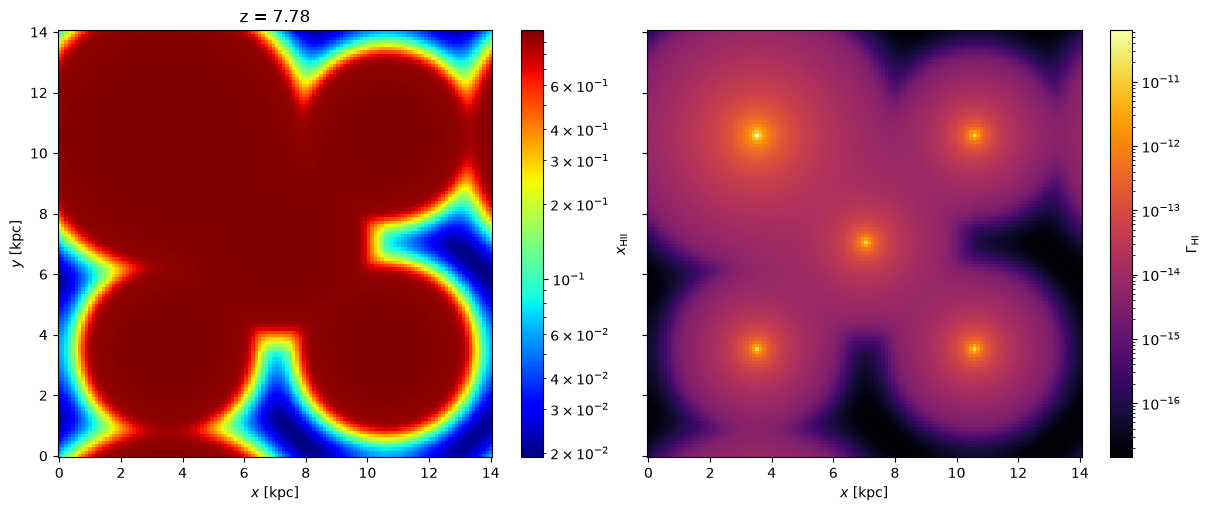

<Figure size 640x480 with 0 Axes>

In [26]:
sim_b, srcpos_b, srcflux_b, timer_b = run_multi_sources('validation/parameters_mult_bright.yml', 'validation/src_mult_bright.txt')

Let's look at the wall clock time at each time step of our simulation.

In [27]:
print(timer_b.summary)


--- TIMER SUMMARY ---
 step 1: 9.23s - t=0
 step 2: 7.05s - t=1
 step 3: 5.37s - t=0
 step 4: 5.32s - t=1
 step 5: 5.36s - t=0
 step 6: 5.47s - t=1
 step 7: 4.66s - t=0
 step 8: 4.63s - t=1
 step 9: 4.70s - t=0
 step 10: 4.68s - t=1
 step 11: 4.65s - t=0
 step 12: 3.85s - t=1
 step 13: 4.02s - t=0
 step 14: 3.81s - t=1
 step 15: 3.94s - t=0
 step 16: 3.86s - t=1
 step 17: 4.05s - t=0
 step 18: 3.93s - t=1
Elapsed time: 1m 29.16s 


Check that each source contributes according to its own flux: photoionization rate at each source cell (Fortran indexing in the source file), for both cases.

In [28]:
src_b = np.loadtxt('validation/src_mult_bright.txt', skiprows=1)
print(f"{'source (i,j,k)':>16} {'flux 3b [1/s]':>14} {'Gamma 3a':>10} {'Gamma 3b':>10} {'3b/3a':>7}")
for i, j, k, flux, _ in src_b:
    i, j, k = int(i) - 1, int(j) - 1, int(k) - 1
    g_a, g_b = sim_a.phi_ion[i, j, k], sim_b.phi_ion[i, j, k]
    print(f'{str((i+1, j+1, k+1)):>16} {flux:14.1e} {g_a:10.2e} {g_b:10.2e} {g_b/g_a:7.1f}')

  source (i,j,k)  flux 3b [1/s]   Gamma 3a   Gamma 3b   3b/3a
    (64, 64, 64)        1.2e+48   3.35e-12   8.39e-13     0.3
    (32, 96, 64)        1.2e+48   3.34e-12   8.35e-13     0.2
    (32, 32, 64)        1.2e+48   3.34e-12   8.35e-13     0.2
    (96, 32, 64)        5.0e+48   3.34e-12   3.34e-12     1.0
    (96, 96, 64)        1.2e+48   3.35e-12   8.36e-13     0.2


## Validation notes

Record here, for each test case and each system/build run on: detected
hardware, detected backend, and outcome (e.g. max/mean relative
difference between HIP and CUDA `sim.xh`/`sim.phi_ion`, and for the
I-front case, agreement with the analytical solution) — before accepting
PR #19.

**Dardel-GPU, AMD MI250X (one GCD), HIP build, `hip_port` at `af393af`** — passed.
- Detection: AMD GPU and HIP build, native combination.
- 1. I-front: numerical I-front radius and velocity follow the analytical solution.
- 2. Shadow: shadow forms behind the clump; the clump stays neutral.
- 3a. Equal sources vs. a CPU-raytracing run of the same case: volume-averaged ionized fraction identical to 4 digits at every redshift; per cell, mean |Δx_HII| ≈ 0.02 (the largest differences, up to 0.4, are in the few cells at the I-fronts) and median relative difference of the photoionization rate ≈ 0.1–0.14.
- 3b. One brighter source: the rate at each source cell scales with that source's own flux (bright 1.0×, the others 0.25× of 3a).
- `pytest tests` (33 tests) passes on the same build.
- To do: rerun after PR #19 is merged; CUDA and HIP builds on Arrhenius (HIP vs. CUDA comparison).